# Notebook 04 - Batch Feature Matching and RANSAC Evaluation

This notebook continues the feature case study from notebook `03` and turns it into a dataset-level experiment. It evaluates the same implemented local-feature pipelines on adjacent image pairs.

Pipeline contract:

1. Notebook/script `02` writes preprocessed images to `data/preprocessing/<split>/feature_gray/<scene>`.
2. Notebook/script `03` writes feature artifacts to `data/feature_extract/<split>/<scene>/<descriptor>`.
3. This notebook reads the saved feature artifacts from `data/feature_extract`, then performs descriptor matching, Lowe ratio filtering, homography estimation, RANSAC filtering, reprojection-error measurement, and reporting.

The notebook can recompute missing features as an explicit fallback, but the default is to require the saved feature cache so the pipeline remains preprocessing -> feature extraction -> matching/RANSAC.

Main outputs:

- `outputs/batch_feature_matching/pair_metrics.csv`
- `outputs/batch_feature_matching/scene_method_summary.csv`
- `outputs/batch_feature_matching/method_summary.csv`
- optional match visualizations in `outputs/batch_feature_matching/matches/`
- report-ready plots and montages in `outputs/batch_feature_matching/plots/`



## Experiment Workflow

1. Load project paths, metadata helpers, and the feature extraction implementation used by the project scripts.
2. Define the four selected method pipelines so the batch experiment matches notebook `03` and the report.
3. Build an inventory of available preprocessed scene folders.
4. For each selected scene, extract features for each method once per image.
5. Match each adjacent image pair using KNN + Lowe ratio test.
6. Estimate a homography with RANSAC and compute inliers, inlier ratio, reprojection error, and spatial coverage.
7. Save pair-level, scene-level, and method-level summary CSV files.
8. Create status distributions, heatmaps, per-scene pair timelines, and metric distribution plots.
9. Optionally export match previews and a montage for selected success, hard-valid, and failure examples.

## 1. Setup


In [1]:
from __future__ import annotations

from argparse import Namespace
from pathlib import Path
import json
import math
import shutil
import sys
import time

import cv2
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown:
        def __init__(self, text: str) -> None:
            self.text = text

        def __str__(self) -> str:
            return self.text

    def display(value):
        print(value)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)



## 2. Paths and Project Imports


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data" / "split").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not find a project root containing data/split and scripts")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import list_scene_dirs, ordered_scene_files
from scripts.PhamHungSon_15_extract_features import extract_features

SPLIT_ROOT = PROJECT_ROOT / "data" / "split"
PREPROCESSING_ROOT = PROJECT_ROOT / "data" / "preprocessing"
FEATURE_EXTRACT_ROOT = PROJECT_ROOT / "data" / "feature_extract"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "batch_feature_matching"
MATCH_OUTPUT_DIR = OUTPUT_ROOT / "matches"
PLOT_OUTPUT_DIR = OUTPUT_ROOT / "plots"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREPROCESSING_ROOT:", PREPROCESSING_ROOT)
print("FEATURE_EXTRACT_ROOT:", FEATURE_EXTRACT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)



PROJECT_ROOT: C:\Users\PC\Downloads\Project
PREPROCESSING_ROOT: C:\Users\PC\Downloads\Project\data\preprocessing
FEATURE_EXTRACT_ROOT: C:\Users\PC\Downloads\Project\data\feature_extract
OUTPUT_ROOT: C:\Users\PC\Downloads\Project\outputs\batch_feature_matching


## 3. Method Pipelines

The table below fixes the detector, descriptor, distance metric, and matching logic for each method. These are the same method families described in the report and in notebook `03`.

The status labels later in this notebook are our experiment flags, not OpenCV labels:

- `success`: enough geometrically consistent matches for a strong adjacent-pair homography.
- `hard_valid`: the pair is usable but weak, so it should be interpreted as a difficult case.
- `failure`: the pair does not provide enough reliable geometry under the selected thresholds.


In [3]:
METHOD_PIPELINES = [
    {
        "method": "ORB",
        "detector": "FAST corners with image pyramid",
        "descriptor": "oriented BRIEF binary string",
        "distance": "Hamming",
        "norm": cv2.NORM_HAMMING,
        "notes": "Fast binary baseline; can be sensitive to repeated texture.",
    },
    {
        "method": "AKAZE",
        "detector": "nonlinear scale space",
        "descriptor": "MLDB binary descriptor",
        "distance": "Hamming",
        "norm": cv2.NORM_HAMMING,
        "notes": "Stronger binary alternative; often more robust but can be slower than ORB.",
    },
    {
        "method": "HARRIS_HOG",
        "detector": "Harris corners",
        "descriptor": "local HOG patch histogram",
        "distance": "L2",
        "norm": cv2.NORM_L2,
        "notes": "Interpretable classical gradient baseline with weaker distinctiveness.",
    },
    {
        "method": "SIFT",
        "detector": "DoG scale-space extrema",
        "descriptor": "128-D gradient histogram",
        "distance": "L2",
        "norm": cv2.NORM_L2,
        "notes": "Strong scale and rotation invariance; slower but usually stable.",
    },
]

PIPELINE_DF = pd.DataFrame(METHOD_PIPELINES).drop(columns=["norm"])
METHOD_NORMS = {row["method"]: row["norm"] for row in METHOD_PIPELINES}
METHODS = [row["method"] for row in METHOD_PIPELINES]
PIPELINE_DF

,method,detector,descriptor,distance,notes
0,ORB,FAST corners with image pyramid,oriented BRIEF binary string,Hamming,Fast binary baseline; can be sensitive to repe...
1,AKAZE,nonlinear scale space,MLDB binary descriptor,Hamming,Stronger binary alternative; often more robust...
2,HARRIS_HOG,Harris corners,local HOG patch histogram,L2,Interpretable classical gradient baseline with...
3,SIFT,DoG scale-space extrema,128-D gradient histogram,L2,Strong scale and rotation invariance; slower b...


## 4. Experiment Configuration

By default this notebook reads feature arrays saved by notebook/script `03` in `data/feature_extract`. If those artifacts are missing, run:

```powershell
conda run -n image_recognition python scripts\PhamHungSon_15_extract_features.py --descriptor all --overwrite
```



In [4]:
SPLITS_TO_RUN = ["test", "failure_analysis"]
INPUT_KIND = "feature_gray"

# Keep this False while developing the notebook. Set True for the final full-dataset table.
RUN_FULL_BATCH = True

# Used when RUN_FULL_BATCH is False.
SELECTED_SPLIT = "test"
SELECTED_SCENES = ["scene_36", "scene_01"]

# Notebook 04 should consume feature artifacts from notebook/script 03.
USE_FEATURE_CACHE = True
RECOMPUTE_MISSING_FEATURES = False
VALIDATE_FEATURE_CACHE_METADATA = True
CLEAN_GENERATED_VISUALS = True

# Feature extraction parameters match scripts/PhamHungSon_15_extract_features.py defaults.
MAX_FEATURES = 4000
ORB_FAST_THRESHOLD = 10
HARRIS_MAX_CORNERS = 1500
HARRIS_QUALITY = 0.01
HARRIS_MIN_DISTANCE = 8.0
HOG_PATCH_SIZE = 32
HOG_CELLS = 4
HOG_BINS = 8

LOWE_RATIO = 0.75
RANSAC_REPROJ_THRESHOLD = 4.0
MIN_GOOD_MATCHES_FOR_H = 4

# Pair status thresholds. These are project-level heuristics used for reporting.
SUCCESS_MIN_INLIERS = 30
SUCCESS_MIN_INLIER_RATIO = 0.35
SUCCESS_MAX_REPROJ_ERROR = 4.0
HARD_MIN_INLIERS = 12
HARD_MIN_INLIER_RATIO = 0.18
HARD_MAX_REPROJ_ERROR = 8.0

SAVE_MATCH_PREVIEWS = True
MAX_MATCH_PREVIEWS_PER_STATUS = 4
DRAW_MATCH_LIMIT = 80

PLOT_ALL_FAILURE_ANALYSIS_SCENES = True
AUTO_DIAGNOSTIC_SCENES_PER_SPLIT = 1
TOP_WEAK_PAIR_COUNT = 20

FEATURE_ARGS = Namespace(
    max_features=MAX_FEATURES,
    orb_fast_threshold=ORB_FAST_THRESHOLD,
    harris_max_corners=HARRIS_MAX_CORNERS,
    harris_quality=HARRIS_QUALITY,
    harris_min_distance=HARRIS_MIN_DISTANCE,
    hog_patch_size=HOG_PATCH_SIZE,
    hog_cells=HOG_CELLS,
    hog_bins=HOG_BINS,
)

FEATURE_PARAMETER_EXPECTED = {
    "max_features": MAX_FEATURES,
    "orb_fast_threshold": ORB_FAST_THRESHOLD,
    "harris_max_corners": HARRIS_MAX_CORNERS,
    "harris_quality": HARRIS_QUALITY,
    "harris_min_distance": HARRIS_MIN_DISTANCE,
    "hog_patch_size": HOG_PATCH_SIZE,
    "hog_cells": HOG_CELLS,
    "hog_bins": HOG_BINS,
}





## 5. Dataset Inventory


In [5]:
def scene_sort_key(path: Path) -> tuple[int, str]:
    digits = "".join(ch for ch in path.name if ch.isdigit())
    return (int(digits) if digits else 10**9, path.name)


def relative_to_project(path: Path | None) -> str:
    if path is None:
        return ""
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT)).replace("\\", "/")
    except ValueError:
        return str(path)


def preprocessing_scene_dir(split_name: str, scene_id: str) -> Path:
    return PREPROCESSING_ROOT / split_name / INPUT_KIND / scene_id


def preprocessed_image_path(split_name: str, scene_id: str, source_image: Path) -> Path:
    return preprocessing_scene_dir(split_name, scene_id) / f"{source_image.stem}.png"


def feature_cache_paths(split_name: str, scene_id: str, method: str, gray_path: Path) -> dict[str, Path]:
    descriptor_dir = FEATURE_EXTRACT_ROOT / split_name / scene_id / method
    return {
        "descriptor_dir": descriptor_dir,
        "feature_file": descriptor_dir / "features" / f"{gray_path.stem}.npz",
        "metadata_file": descriptor_dir / "metadata" / f"{gray_path.stem}.json",
    }


def count_feature_cache_files(split_name: str, scene_id: str, ordered_files: list[Path]) -> tuple[int, int]:
    expected = len(ordered_files) * len(METHODS)
    available = 0
    for method in METHODS:
        for source_image in ordered_files:
            gray_path = preprocessed_image_path(split_name, scene_id, source_image)
            paths = feature_cache_paths(split_name, scene_id, method, gray_path)
            if paths["feature_file"].exists() and paths["metadata_file"].exists():
                available += 1
    return available, expected


def build_inventory() -> pd.DataFrame:
    rows = []
    for split_name in SPLITS_TO_RUN:
        split_dir = SPLIT_ROOT / split_name
        if not split_dir.exists():
            continue
        for scene_dir in sorted(list_scene_dirs(split_dir), key=scene_sort_key):
            ordered_files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
            pre_dir = preprocessing_scene_dir(split_name, scene_dir.name)
            available = sum(1 for image_path in ordered_files if preprocessed_image_path(split_name, scene_dir.name, image_path).exists())
            feature_available, feature_expected = count_feature_cache_files(split_name, scene_dir.name, ordered_files)
            rows.append(
                {
                    "split": split_name,
                    "scene_id": scene_dir.name,
                    "ordered_images": len(ordered_files),
                    "adjacent_pairs": max(len(ordered_files) - 1, 0),
                    "preprocessed_images": available,
                    "preprocessing_ready": available == len(ordered_files),
                    "feature_cache_files": feature_available,
                    "feature_cache_expected": feature_expected,
                    "feature_cache_ready": feature_available == feature_expected,
                    "category": meta.get("category"),
                    "difficulty": meta.get("difficulty"),
                    "recommended_use": meta.get("recommended_use"),
                    "used_meta_order": used_meta_order,
                    "reference_images": len(reference_files),
                }
            )
    return pd.DataFrame(rows)


inventory_df = build_inventory()
display(inventory_df)

if not inventory_df.empty:
    display(
        inventory_df.groupby(["split", "preprocessing_ready", "feature_cache_ready"], dropna=False)
        .agg(scenes=("scene_id", "count"), pairs=("adjacent_pairs", "sum"))
        .reset_index()
    )



,split,scene_id,ordered_images,adjacent_pairs,preprocessed_images,preprocessing_ready,feature_cache_files,feature_cache_expected,feature_cache_ready,category,difficulty,recommended_use,used_meta_order,reference_images
0,test,scene_01,6,5,6,True,24,24,True,success,medium,core_benchmark,True,0
1,test,scene_24,5,4,5,True,20,20,True,success,medium,large_stress_test,True,0
2,test,scene_28,6,5,6,True,24,24,True,success,medium,core_benchmark,True,0
3,test,scene_33,6,5,6,True,24,24,True,success,medium,core_benchmark,True,0
4,test,scene_36,5,4,5,True,20,20,True,hard_valid,medium,core_hard_benchmark,True,0
5,test,scene_40,8,7,8,True,32,32,True,success,medium,large_stress_test,True,0
6,failure_analysis,scene_03,4,3,4,True,16,16,True,hard_valid,hard,failure_analysis,True,0
7,failure_analysis,scene_04,3,2,3,True,12,12,True,failure,hard,failure_analysis,True,0
8,failure_analysis,scene_06,5,4,5,True,20,20,True,hard_valid,hard,failure_analysis,True,0
9,failure_analysis,scene_07,6,5,6,True,24,24,True,hard_valid,hard,failure_analysis,True,0


,split,preprocessing_ready,feature_cache_ready,scenes,pairs
0,failure_analysis,True,True,13,55
1,test,True,True,6,30


## 6. Feature, Matching, and Geometry Helpers


In [6]:
def load_gray_image(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return image




def clear_directory_contents(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)
    for child in path.iterdir():
        if child.is_dir():
            shutil.rmtree(child)
        else:
            child.unlink()

def load_feature_metadata(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def feature_parameters_match(actual: dict, expected: dict) -> bool:
    for key, expected_value in expected.items():
        if key not in actual:
            return False
        actual_value = actual[key]
        if isinstance(expected_value, float):
            if not math.isclose(float(actual_value), expected_value, rel_tol=1e-9, abs_tol=1e-12):
                return False
        elif actual_value != expected_value:
            return False
    return True


def validate_feature_metadata(metadata: dict, split_name: str, scene_id: str, method: str, gray_path: Path) -> None:
    if metadata.get("status") not in {"ok", "existing"}:
        raise ValueError(f"Cached feature status is {metadata.get('status')!r}")
    if metadata.get("split") != split_name or metadata.get("scene") != scene_id:
        raise ValueError(
            f"Cached feature belongs to {metadata.get('split')}/{metadata.get('scene')}, expected {split_name}/{scene_id}"
        )
    if metadata.get("descriptor") != method:
        raise ValueError(f"Cached descriptor is {metadata.get('descriptor')}, expected {method}")
    expected_source = relative_to_project(gray_path)
    if metadata.get("source_image") != expected_source:
        raise ValueError(f"Cached source image is {metadata.get('source_image')}, expected {expected_source}")
    if not feature_parameters_match(metadata.get("parameters", {}), FEATURE_PARAMETER_EXPECTED):
        raise ValueError("Cached feature parameters do not match notebook 04 configuration")


def keypoints_from_array(keypoint_array: np.ndarray) -> list[cv2.KeyPoint]:
    keypoints = []
    if keypoint_array is None:
        return keypoints
    for row in np.asarray(keypoint_array, dtype=np.float32):
        if len(row) < 7:
            continue
        x, y, size, angle, response, octave, class_id = row[:7]
        keypoints.append(
            cv2.KeyPoint(
                float(x),
                float(y),
                max(float(size), 1e-6),
                float(angle),
                float(response),
                int(octave),
                int(class_id),
            )
        )
    return keypoints


def load_cached_features(split_name: str, scene_id: str, gray_path: Path, method: str) -> dict:
    paths = feature_cache_paths(split_name, scene_id, method, gray_path)
    if not paths["feature_file"].exists() or not paths["metadata_file"].exists():
        raise FileNotFoundError(
            "Missing cached features for "
            f"{split_name}/{scene_id}/{method}/{gray_path.stem}. "
            "Run scripts/PhamHungSon_15_extract_features.py first."
        )

    metadata = load_feature_metadata(paths["metadata_file"])
    if VALIDATE_FEATURE_CACHE_METADATA:
        validate_feature_metadata(metadata, split_name, scene_id, method, gray_path)

    with np.load(paths["feature_file"], allow_pickle=False) as archive:
        keypoints = keypoints_from_array(archive["keypoints"])
        descriptors = archive["descriptors"]
        image_shape = tuple(int(value) for value in archive["image_shape"].tolist())

    return {
        "keypoints": keypoints,
        "descriptors": descriptors,
        "runtime_sec": float(metadata.get("runtime_sec", 0.0)),
        "image_shape": image_shape,
        "feature_source": "cache",
        "feature_file": relative_to_project(paths["feature_file"]),
        "metadata_file": relative_to_project(paths["metadata_file"]),
    }


def ensure_descriptor_type(descriptors: np.ndarray | None, norm: int) -> np.ndarray | None:
    if descriptors is None:
        return None
    if descriptors.ndim == 1:
        descriptors = descriptors.reshape(1, -1)
    if len(descriptors) == 0:
        return descriptors
    if norm == cv2.NORM_HAMMING:
        return descriptors.astype(np.uint8, copy=False)
    return descriptors.astype(np.float32, copy=False)


def extract_one_image(gray: np.ndarray, method: str) -> dict:
    start = time.perf_counter()
    keypoints, descriptors = extract_features(gray, method, FEATURE_ARGS)
    runtime = time.perf_counter() - start
    return {
        "keypoints": list(keypoints or []),
        "descriptors": descriptors,
        "runtime_sec": runtime,
        "image_shape": gray.shape[:2],
        "feature_source": "computed",
        "feature_file": "",
        "metadata_file": "",
    }


def load_or_extract_features(item: dict, split_name: str, scene_id: str, method: str) -> dict:
    if USE_FEATURE_CACHE:
        try:
            return load_cached_features(split_name, scene_id, item["gray_path"], method)
        except Exception:
            if not RECOMPUTE_MISSING_FEATURES:
                raise
    return extract_one_image(item["gray"], method)


def match_descriptors(desc_a: np.ndarray | None, desc_b: np.ndarray | None, norm: int) -> tuple[list, list, list[float]]:
    desc_a = ensure_descriptor_type(desc_a, norm)
    desc_b = ensure_descriptor_type(desc_b, norm)
    if desc_a is None or desc_b is None or len(desc_a) < 2 or len(desc_b) < 2:
        return [], [], []

    matcher = cv2.BFMatcher(norm, crossCheck=False)
    raw_pairs = matcher.knnMatch(desc_a, desc_b, k=2)

    good_matches = []
    ratios = []
    for pair in raw_pairs:
        if len(pair) < 2:
            continue
        first, second = pair
        if second.distance <= 1e-12:
            ratio = math.inf
        else:
            ratio = float(first.distance / second.distance)
        ratios.append(ratio)
        if first.distance < LOWE_RATIO * second.distance:
            good_matches.append(first)
    return raw_pairs, good_matches, ratios


def reprojection_errors(src_points: np.ndarray, dst_points: np.ndarray, homography: np.ndarray) -> np.ndarray:
    projected = cv2.perspectiveTransform(src_points.reshape(-1, 1, 2), homography).reshape(-1, 2)
    return np.linalg.norm(projected - dst_points.reshape(-1, 2), axis=1)


def point_coverage(points: np.ndarray, image_shape: tuple[int, int]) -> float:
    if points is None or len(points) < 3:
        return 0.0
    height, width = image_shape[:2]
    x_min, y_min = points.min(axis=0)
    x_max, y_max = points.max(axis=0)
    bbox_area = max(float(x_max - x_min), 0.0) * max(float(y_max - y_min), 0.0)
    return float(bbox_area / max(float(width * height), 1.0))


def classify_pair(inliers: int, inlier_ratio: float, reproj_error: float | None, homography_ok: bool) -> str:
    if not homography_ok or reproj_error is None or not np.isfinite(reproj_error):
        return "failure"
    if (
        inliers >= SUCCESS_MIN_INLIERS
        and inlier_ratio >= SUCCESS_MIN_INLIER_RATIO
        and reproj_error <= SUCCESS_MAX_REPROJ_ERROR
    ):
        return "success"
    if (
        inliers >= HARD_MIN_INLIERS
        and inlier_ratio >= HARD_MIN_INLIER_RATIO
        and reproj_error <= HARD_MAX_REPROJ_ERROR
    ):
        return "hard_valid"
    return "failure"


def evaluate_pair_features(feature_a: dict, feature_b: dict, method: str) -> dict:
    keypoints_a = feature_a["keypoints"]
    keypoints_b = feature_b["keypoints"]
    norm = METHOD_NORMS[method]

    try:
        raw_pairs, good_matches, lowe_ratios = match_descriptors(
            feature_a["descriptors"],
            feature_b["descriptors"],
            norm,
        )
    except cv2.error as exc:
        return {
            "keypoints_a": len(keypoints_a),
            "keypoints_b": len(keypoints_b),
            "raw_matches": 0,
            "good_matches": 0,
            "lowe_pass_rate": 0.0,
            "median_lowe_ratio": np.nan,
            "homography_ok": False,
            "inliers": 0,
            "inlier_ratio": 0.0,
            "reprojection_error_mean": np.nan,
            "reprojection_error_median": np.nan,
            "coverage_a": 0.0,
            "coverage_b": 0.0,
            "coverage_min": 0.0,
            "status": "failure",
            "error": str(exc),
            "matches_for_preview": [],
            "inlier_mask_for_preview": None,
        }

    homography = None
    mask = None
    inliers = 0
    inlier_ratio = 0.0
    mean_error = np.nan
    median_error = np.nan
    coverage_a = 0.0
    coverage_b = 0.0

    if len(good_matches) >= MIN_GOOD_MATCHES_FOR_H:
        src = np.float32([keypoints_a[m.queryIdx].pt for m in good_matches])
        dst = np.float32([keypoints_b[m.trainIdx].pt for m in good_matches])
        homography, mask = cv2.findHomography(
            src.reshape(-1, 1, 2),
            dst.reshape(-1, 1, 2),
            cv2.RANSAC,
            RANSAC_REPROJ_THRESHOLD,
        )
        if mask is not None:
            inlier_mask = mask.ravel().astype(bool)
            inliers = int(inlier_mask.sum())
            inlier_ratio = float(inliers / max(len(good_matches), 1))
            if homography is not None and inliers > 0:
                errors = reprojection_errors(src[inlier_mask], dst[inlier_mask], homography)
                mean_error = float(np.mean(errors))
                median_error = float(np.median(errors))
                coverage_a = point_coverage(src[inlier_mask], feature_a["image_shape"])
                coverage_b = point_coverage(dst[inlier_mask], feature_b["image_shape"])

    homography_ok = homography is not None and inliers >= MIN_GOOD_MATCHES_FOR_H
    status = classify_pair(inliers, inlier_ratio, mean_error, homography_ok)

    finite_ratios = [ratio for ratio in lowe_ratios if np.isfinite(ratio)]
    return {
        "keypoints_a": len(keypoints_a),
        "keypoints_b": len(keypoints_b),
        "raw_matches": len(raw_pairs),
        "good_matches": len(good_matches),
        "lowe_pass_rate": float(len(good_matches) / max(len(raw_pairs), 1)),
        "median_lowe_ratio": float(np.median(finite_ratios)) if finite_ratios else np.nan,
        "homography_ok": bool(homography_ok),
        "inliers": inliers,
        "inlier_ratio": inlier_ratio,
        "reprojection_error_mean": mean_error,
        "reprojection_error_median": median_error,
        "coverage_a": coverage_a,
        "coverage_b": coverage_b,
        "coverage_min": min(coverage_a, coverage_b),
        "status": status,
        "error": "",
        "matches_for_preview": good_matches,
        "inlier_mask_for_preview": None if mask is None else mask.ravel().astype(bool),
    }




## 7. Scene Runner


In [7]:
def selected_scene_records() -> list[tuple[str, Path]]:
    if RUN_FULL_BATCH:
        selected = []
        for split_name in SPLITS_TO_RUN:
            split_dir = SPLIT_ROOT / split_name
            if split_dir.exists():
                selected.extend((split_name, scene_dir) for scene_dir in sorted(list_scene_dirs(split_dir), key=scene_sort_key))
        return selected

    split_dir = SPLIT_ROOT / SELECTED_SPLIT
    scene_lookup = {scene_dir.name: scene_dir for scene_dir in list_scene_dirs(split_dir)}
    missing = [scene_id for scene_id in SELECTED_SCENES if scene_id not in scene_lookup]
    if missing:
        raise FileNotFoundError(f"Selected scenes not found under {split_dir}: {missing}")
    return [(SELECTED_SPLIT, scene_lookup[scene_id]) for scene_id in SELECTED_SCENES]


def load_scene_grays(split_name: str, scene_dir: Path, ordered_files: list[Path]) -> list[dict]:
    items = []
    for source_path in ordered_files:
        gray_path = preprocessed_image_path(split_name, scene_dir.name, source_path)
        gray = load_gray_image(gray_path)
        items.append({"source_path": source_path, "gray_path": gray_path, "gray": gray})
    return items


def evaluate_scene(split_name: str, scene_dir: Path) -> tuple[list[dict], dict]:
    ordered_files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    if len(ordered_files) < 2:
        return [], {"scene_id": scene_dir.name, "warning": "fewer than two ordered images"}

    scene_grays = load_scene_grays(split_name, scene_dir, ordered_files)
    rows = []
    preview_payloads = []

    for method in METHODS:
        features = []
        for item in scene_grays:
            features.append(load_or_extract_features(item, split_name, scene_dir.name, method))

        for pair_index in range(len(scene_grays) - 1):
            feature_a = features[pair_index]
            feature_b = features[pair_index + 1]
            result = evaluate_pair_features(feature_a, feature_b, method)

            row = {
                "split": split_name,
                "scene_id": scene_dir.name,
                "pair_id": f"pair_{pair_index + 1:02d}",
                "pair_index": pair_index + 1,
                "image_a": ordered_files[pair_index].name,
                "image_b": ordered_files[pair_index + 1].name,
                "method": method,
                "feature_source_a": feature_a["feature_source"],
                "feature_source_b": feature_b["feature_source"],
                "feature_file_a": feature_a["feature_file"],
                "feature_file_b": feature_b["feature_file"],
                "keypoints_a": result["keypoints_a"],
                "keypoints_b": result["keypoints_b"],
                "raw_matches": result["raw_matches"],
                "good_matches": result["good_matches"],
                "lowe_pass_rate": result["lowe_pass_rate"],
                "median_lowe_ratio": result["median_lowe_ratio"],
                "homography_ok": result["homography_ok"],
                "inliers": result["inliers"],
                "inlier_ratio": result["inlier_ratio"],
                "reprojection_error_mean": result["reprojection_error_mean"],
                "reprojection_error_median": result["reprojection_error_median"],
                "coverage_a": result["coverage_a"],
                "coverage_b": result["coverage_b"],
                "coverage_min": result["coverage_min"],
                "feature_runtime_sec": feature_a["runtime_sec"] + feature_b["runtime_sec"],
                "status": result["status"],
                "category": meta.get("category"),
                "difficulty": meta.get("difficulty"),
                "recommended_use": meta.get("recommended_use"),
                "used_meta_order": used_meta_order,
                "error": result["error"],
            }
            rows.append(row)

            preview_payloads.append(
                {
                    "row": row,
                    "image_a": scene_grays[pair_index]["gray"],
                    "image_b": scene_grays[pair_index + 1]["gray"],
                    "keypoints_a": feature_a["keypoints"],
                    "keypoints_b": feature_b["keypoints"],
                    "matches": result["matches_for_preview"],
                    "inlier_mask": result["inlier_mask_for_preview"],
                }
            )

    return rows, {"preview_payloads": preview_payloads}


scene_work = selected_scene_records()
print(f"Scene work items: {len(scene_work)}")
for split_name, scene_dir in scene_work[:10]:
    print(f"- {split_name}/{scene_dir.name}")
if len(scene_work) > 10:
    print(f"... plus {len(scene_work) - 10} more")



Scene work items: 19
- test/scene_01
- test/scene_24
- test/scene_28
- test/scene_33
- test/scene_36
- test/scene_40
- failure_analysis/scene_03
- failure_analysis/scene_04
- failure_analysis/scene_06
- failure_analysis/scene_07
... plus 9 more


## 8. Run Matching Evaluation


In [8]:
if CLEAN_GENERATED_VISUALS:
    clear_directory_contents(MATCH_OUTPUT_DIR)
    clear_directory_contents(PLOT_OUTPUT_DIR)

all_rows = []
all_previews = []
errors = []

for index, (split_name, scene_dir) in enumerate(scene_work, start=1):
    print(f"[{index}/{len(scene_work)}] {split_name}/{scene_dir.name}")
    try:
        rows, extra = evaluate_scene(split_name, scene_dir)
        all_rows.extend(rows)
        all_previews.extend(extra.get("preview_payloads", []))
    except Exception as exc:
        errors.append({"split": split_name, "scene_id": scene_dir.name, "error": str(exc)})
        print(f"  ERROR: {exc}")

pair_df = pd.DataFrame(all_rows)
error_df = pd.DataFrame(errors)

pair_metrics_path = OUTPUT_ROOT / "pair_metrics.csv"
error_path = OUTPUT_ROOT / "errors.csv"

pair_df.to_csv(pair_metrics_path, index=False, encoding="utf-8-sig")
error_df.to_csv(error_path, index=False, encoding="utf-8-sig")

print(f"Saved pair metrics: {pair_metrics_path.relative_to(PROJECT_ROOT)}")
print(f"Saved errors: {error_path.relative_to(PROJECT_ROOT)}")
display(pair_df.head(20))
if not error_df.empty:
    display(error_df)



[1/19] test/scene_01
[2/19] test/scene_24
[3/19] test/scene_28
[4/19] test/scene_33
[5/19] test/scene_36
[6/19] test/scene_40
[7/19] failure_analysis/scene_03
[8/19] failure_analysis/scene_04
[9/19] failure_analysis/scene_06
[10/19] failure_analysis/scene_07
[11/19] failure_analysis/scene_08
[12/19] failure_analysis/scene_11
[13/19] failure_analysis/scene_15
[14/19] failure_analysis/scene_16
[15/19] failure_analysis/scene_18
[16/19] failure_analysis/scene_21
[17/19] failure_analysis/scene_30
[18/19] failure_analysis/scene_32
[19/19] failure_analysis/scene_35
Saved pair metrics: outputs\batch_feature_matching\pair_metrics.csv
Saved errors: outputs\batch_feature_matching\errors.csv


,split,scene_id,pair_id,pair_index,image_a,image_b,method,feature_source_a,feature_source_b,feature_file_a,feature_file_b,keypoints_a,keypoints_b,raw_matches,good_matches,lowe_pass_rate,median_lowe_ratio,homography_ok,inliers,inlier_ratio,reprojection_error_mean,reprojection_error_median,coverage_a,coverage_b,coverage_min,feature_runtime_sec,status,category,difficulty,recommended_use,used_meta_order,error
0,test,scene_01,pair_01,1,img_01.jpg,img_02.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,1015,0.253750,0.878788,True,771,0.759606,1.348110,1.166860,0.338059,0.317290,0.317290,0.125234,success,success,medium,core_benchmark,True,
1,test,scene_01,pair_02,2,img_02.jpg,img_03.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,678,0.169500,0.914286,True,426,0.628319,1.298061,1.081087,0.258384,0.290606,0.258384,0.129681,success,success,medium,core_benchmark,True,
2,test,scene_01,pair_03,3,img_03.jpg,img_04.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,550,0.137500,0.934211,True,322,0.585455,1.158818,1.029856,0.362537,0.368323,0.362537,0.127339,success,success,medium,core_benchmark,True,
3,test,scene_01,pair_04,4,img_04.jpg,img_05.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,325,0.081250,0.951220,True,274,0.843077,0.910525,0.768282,0.163801,0.151390,0.151390,0.129148,success,success,medium,core_benchmark,True,
4,test,scene_01,pair_05,5,img_05.jpg,img_06.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,3810,4000,599,0.149750,0.921875,True,414,0.691152,1.277043,1.137123,0.118296,0.138442,0.118296,0.129880,success,success,medium,core_benchmark,True,
5,test,scene_01,pair_01,1,img_01.jpg,img_02.jpg,AKAZE,cache,cache,data/feature_extract/test/scene_01/AKAZE/featu...,data/feature_extract/test/scene_01/AKAZE/featu...,1340,1496,1340,752,0.561194,0.685489,True,582,0.773936,1.086052,0.960486,0.357950,0.354016,0.354016,0.265620,success,success,medium,core_benchmark,True,
6,test,scene_01,pair_02,2,img_02.jpg,img_03.jpg,AKAZE,cache,cache,data/feature_extract/test/scene_01/AKAZE/featu...,data/feature_extract/test/scene_01/AKAZE/featu...,1496,2693,1496,529,0.353610,0.854545,True,346,0.654064,1.077754,0.896233,0.286296,0.300294,0.286296,0.273162,success,success,medium,core_benchmark,True,
7,test,scene_01,pair_03,3,img_03.jpg,img_04.jpg,AKAZE,cache,cache,data/feature_extract/test/scene_01/AKAZE/featu...,data/feature_extract/test/scene_01/AKAZE/featu...,2693,2401,2693,512,0.190123,0.931818,True,298,0.582031,0.684382,0.603719,0.141642,0.145110,0.141642,0.291663,success,success,medium,core_benchmark,True,
8,test,scene_01,pair_04,4,img_04.jpg,img_05.jpg,AKAZE,cache,cache,data/feature_extract/test/scene_01/AKAZE/featu...,data/feature_extract/test/scene_01/AKAZE/featu...,2401,1142,2401,287,0.119534,0.950355,True,210,0.731707,0.772452,0.685499,0.158757,0.138263,0.138263,0.296613,success,success,medium,core_benchmark,True,
9,test,scene_01,pair_05,5,img_05.jpg,img_06.jpg,AKAZE,cache,cache,data/feature_extract/test/scene_01/AKAZE/featu...,data/feature_extract/test/scene_01/AKAZE/featu...,1142,609,1142,360,0.315236,0.879815,True,241,0.669444,0.968993,0.805143,0.129816,0.146398,0.129816,0.271560,success,success,medium,core_benchmark,True,


## 9. Summary Tables


In [9]:
def summarize_pairs(pair_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    if pair_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    scene_summary = (
        pair_df.assign(
            success_count=(pair_df["status"] == "success").astype(int),
            hard_valid_count=(pair_df["status"] == "hard_valid").astype(int),
            failure_count=(pair_df["status"] == "failure").astype(int),
        )
        .groupby(["split", "scene_id", "method"], dropna=False)
        .agg(
            pairs=("pair_id", "count"),
            success_count=("success_count", "sum"),
            hard_valid_count=("hard_valid_count", "sum"),
            failure_count=("failure_count", "sum"),
            median_inliers=("inliers", "median"),
            median_inlier_ratio=("inlier_ratio", "median"),
            median_reprojection_error=("reprojection_error_mean", "median"),
            median_coverage_min=("coverage_min", "median"),
            median_runtime_sec=("feature_runtime_sec", "median"),
            difficulty=("difficulty", "first"),
            category=("category", "first"),
        )
        .reset_index()
    )
    scene_summary["success_rate"] = scene_summary["success_count"] / scene_summary["pairs"].clip(lower=1)
    scene_summary["usable_rate"] = (scene_summary["success_count"] + scene_summary["hard_valid_count"]) / scene_summary["pairs"].clip(lower=1)

    method_summary = (
        pair_df.assign(
            success_count=(pair_df["status"] == "success").astype(int),
            hard_valid_count=(pair_df["status"] == "hard_valid").astype(int),
            failure_count=(pair_df["status"] == "failure").astype(int),
        )
        .groupby(["split", "method"], dropna=False)
        .agg(
            pairs=("pair_id", "count"),
            scenes=("scene_id", "nunique"),
            success_count=("success_count", "sum"),
            hard_valid_count=("hard_valid_count", "sum"),
            failure_count=("failure_count", "sum"),
            median_good_matches=("good_matches", "median"),
            median_inliers=("inliers", "median"),
            median_inlier_ratio=("inlier_ratio", "median"),
            median_reprojection_error=("reprojection_error_mean", "median"),
            median_coverage_min=("coverage_min", "median"),
            median_runtime_sec=("feature_runtime_sec", "median"),
        )
        .reset_index()
    )
    method_summary["success_rate"] = method_summary["success_count"] / method_summary["pairs"].clip(lower=1)
    method_summary["usable_rate"] = (method_summary["success_count"] + method_summary["hard_valid_count"]) / method_summary["pairs"].clip(lower=1)
    return scene_summary, method_summary


scene_summary_df, method_summary_df = summarize_pairs(pair_df)
scene_summary_path = OUTPUT_ROOT / "scene_method_summary.csv"
method_summary_path = OUTPUT_ROOT / "method_summary.csv"

scene_summary_df.to_csv(scene_summary_path, index=False, encoding="utf-8-sig")
method_summary_df.to_csv(method_summary_path, index=False, encoding="utf-8-sig")

print(f"Saved scene summary: {scene_summary_path.relative_to(PROJECT_ROOT)}")
print(f"Saved method summary: {method_summary_path.relative_to(PROJECT_ROOT)}")

display(method_summary_df.sort_values(["split", "usable_rate", "median_inliers"], ascending=[True, False, False]))
display(scene_summary_df.sort_values(["split", "scene_id", "usable_rate"], ascending=[True, True, False]).head(30))


Saved scene summary: outputs\batch_feature_matching\scene_method_summary.csv
Saved method summary: outputs\batch_feature_matching\method_summary.csv


,split,method,pairs,scenes,success_count,hard_valid_count,failure_count,median_good_matches,median_inliers,median_inlier_ratio,median_reprojection_error,median_coverage_min,median_runtime_sec,success_rate,usable_rate
3,failure_analysis,SIFT,55,13,41,8,6,337.0,183.0,0.565347,1.248360,0.176276,0.962608,0.745455,0.890909
0,failure_analysis,AKAZE,55,13,42,6,7,320.0,201.0,0.591205,1.307894,0.165577,0.440567,0.763636,0.872727
2,failure_analysis,ORB,55,13,46,2,7,291.0,191.0,0.587209,1.374597,0.144815,0.200203,0.836364,0.872727
1,failure_analysis,HARRIS_HOG,55,13,35,10,10,112.0,68.0,0.674419,1.274275,0.151436,1.364812,0.636364,0.818182
4,test,AKAZE,30,6,30,0,0,518.5,320.0,0.644893,1.610423,0.283428,0.330333,1.000000,1.000000
6,test,ORB,30,6,28,2,0,414.5,263.0,0.649260,1.440916,0.177703,0.170212,0.933333,1.000000
7,test,SIFT,30,6,28,1,1,505.5,332.0,0.589938,1.296442,0.293560,0.791653,0.933333,0.966667
5,test,HARRIS_HOG,30,6,23,5,2,112.0,74.5,0.681866,1.337025,0.185949,1.144586,0.766667,0.933333


,split,scene_id,method,pairs,success_count,hard_valid_count,failure_count,median_inliers,median_inlier_ratio,median_reprojection_error,median_coverage_min,median_runtime_sec,difficulty,category,success_rate,usable_rate
0,failure_analysis,scene_03,AKAZE,3,3,0,0,225.0,0.577778,1.540357,0.332073,0.315236,hard,hard_valid,1.000000,1.00
1,failure_analysis,scene_03,HARRIS_HOG,3,3,0,0,106.0,0.634021,1.395917,0.329141,1.359875,hard,hard_valid,1.000000,1.00
2,failure_analysis,scene_03,ORB,3,3,0,0,210.0,0.587209,1.336405,0.288955,0.171218,hard,hard_valid,1.000000,1.00
3,failure_analysis,scene_03,SIFT,3,3,0,0,226.0,0.540816,1.325898,0.232654,0.784017,hard,hard_valid,1.000000,1.00
4,failure_analysis,scene_04,AKAZE,2,0,1,1,52.0,0.245838,1.307377,0.041057,0.320500,hard,failure,0.000000,0.50
5,failure_analysis,scene_04,HARRIS_HOG,2,0,1,1,10.5,0.562500,1.427368,0.043478,1.382811,hard,failure,0.000000,0.50
6,failure_analysis,scene_04,ORB,2,1,0,1,18.0,0.349593,1.326131,0.133093,0.179017,hard,failure,0.500000,0.50
7,failure_analysis,scene_04,SIFT,2,1,0,1,39.0,0.287643,1.361601,0.058297,0.797920,hard,failure,0.500000,0.50
8,failure_analysis,scene_06,AKAZE,4,4,0,0,165.5,0.864385,1.194490,0.138126,0.400000,hard,hard_valid,1.000000,1.00
10,failure_analysis,scene_06,ORB,4,4,0,0,369.0,0.795408,1.603964,0.133347,0.153777,hard,hard_valid,1.000000,1.00


## 10. Diagnostic Plots


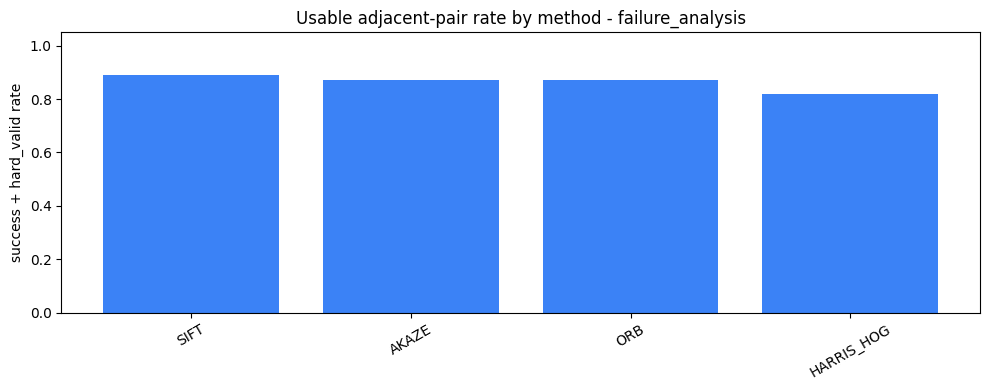

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_usable_rate_by_method.png


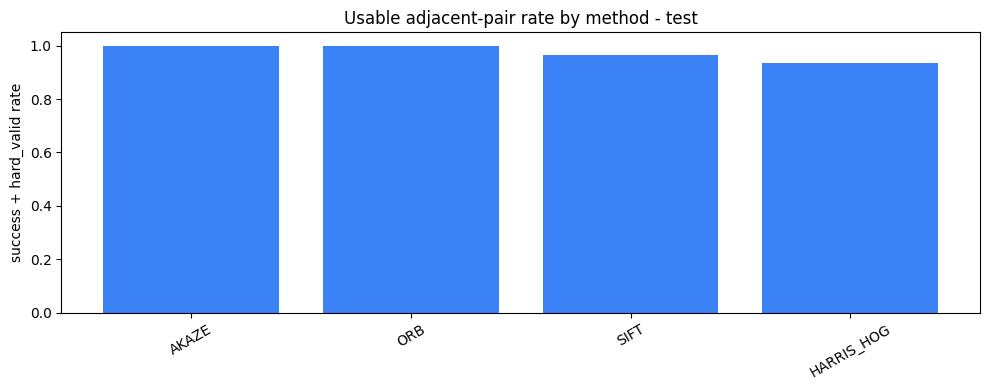

Saved plot: outputs\batch_feature_matching\plots\test_usable_rate_by_method.png


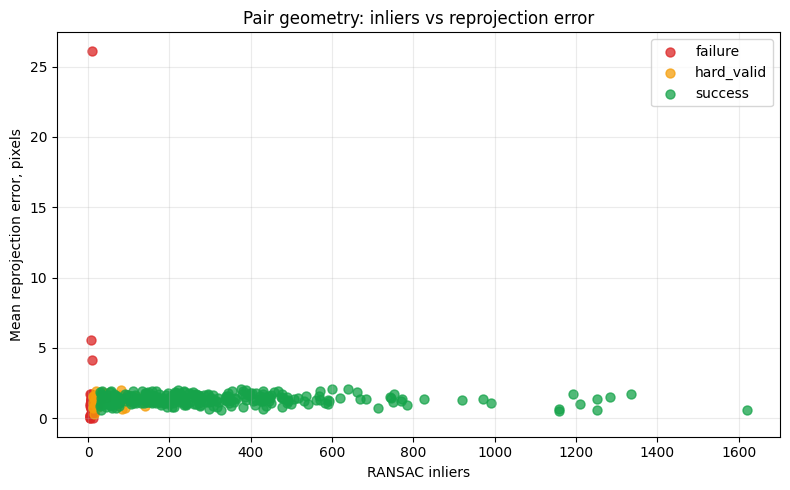

Saved plot: outputs\batch_feature_matching\plots\pair_inliers_vs_reprojection_error.png


In [10]:
if HAS_MATPLOTLIB and not method_summary_df.empty:
    for split_name, split_df in method_summary_df.groupby("split"):
        ordered = split_df.sort_values("usable_rate", ascending=False)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(ordered["method"], ordered["usable_rate"], color="#3b82f6")
        ax.set_title(f"Usable adjacent-pair rate by method - {split_name}")
        ax.set_ylabel("success + hard_valid rate")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=30)
        fig.tight_layout()
        path = PLOT_OUTPUT_DIR / f"{split_name}_usable_rate_by_method.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        plt.show()
        print(f"Saved plot: {path.relative_to(PROJECT_ROOT)}")

if HAS_MATPLOTLIB and not pair_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {"success": "#16a34a", "hard_valid": "#f59e0b", "failure": "#dc2626"}
    for status, status_df in pair_df.groupby("status"):
        ax.scatter(
            status_df["inliers"],
            status_df["reprojection_error_mean"],
            label=status,
            alpha=0.75,
            s=42,
            color=colors.get(status, "#64748b"),
        )
    ax.set_title("Pair geometry: inliers vs reprojection error")
    ax.set_xlabel("RANSAC inliers")
    ax.set_ylabel("Mean reprojection error, pixels")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    path = PLOT_OUTPUT_DIR / "pair_inliers_vs_reprojection_error.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {path.relative_to(PROJECT_ROOT)}")


## 11. Extended Visual Diagnostics

The previous plots give a quick global view. This section adds report-ready visuals at three levels:

- method level: stacked status distribution and metric boxplots
- scene level: method-by-scene usable-rate heatmap
- pair level: one selected scene shown as a status matrix and metric timeline


In [11]:
STATUS_ORDER = ["success", "hard_valid", "failure"]
STATUS_COLORS = {
    "success": "#16a34a",
    "hard_valid": "#f59e0b",
    "failure": "#dc2626",
}
STATUS_SCORE = {"failure": 0, "hard_valid": 1, "success": 2}


def save_plot(fig, filename: str) -> Path:
    output_path = PLOT_OUTPUT_DIR / filename
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved plot: {output_path.relative_to(PROJECT_ROOT)}")
    return output_path


def finite_series(frame: pd.DataFrame, column: str) -> pd.Series:
    return pd.to_numeric(frame[column], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()


def method_color_map() -> dict[str, str]:
    palette = ["#2563eb", "#16a34a", "#f97316", "#9333ea"]
    return {method: palette[index % len(palette)] for index, method in enumerate(METHODS)}

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_status_distribution_by_method.png


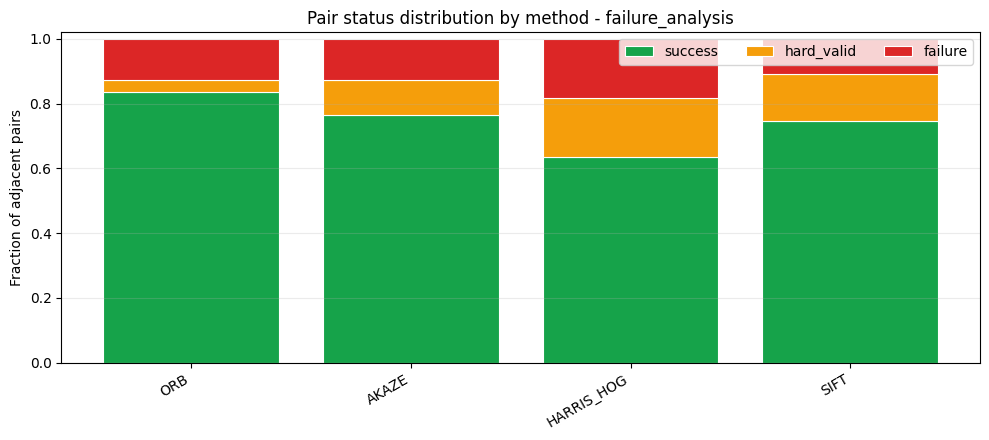

Saved plot: outputs\batch_feature_matching\plots\test_status_distribution_by_method.png


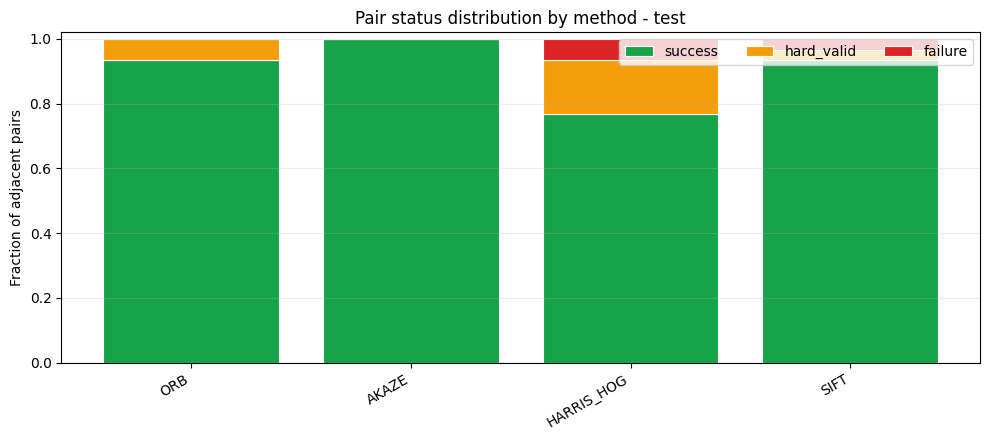

Saved plot: outputs\batch_feature_matching\plots\scene_method_usable_rate_heatmap.png


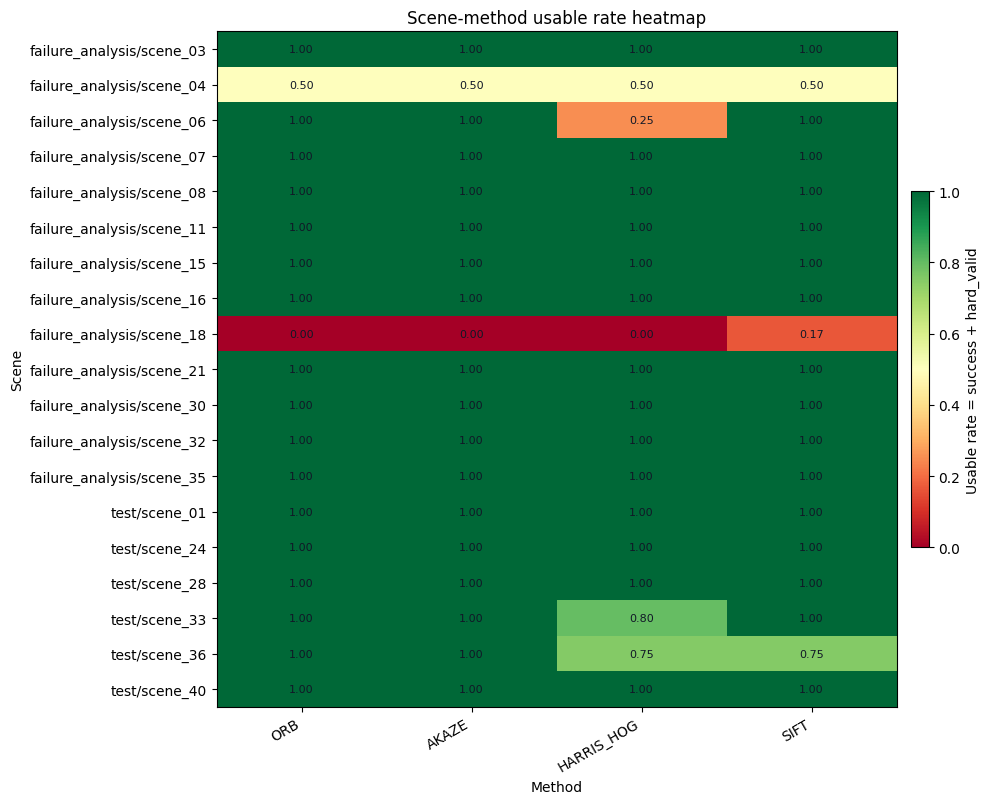

In [12]:
if HAS_MATPLOTLIB and not pair_df.empty:
    status_counts = (
        pair_df.groupby(["split", "method", "status"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=STATUS_ORDER, fill_value=0)
        .reset_index()
    )

    for split_name, split_df in status_counts.groupby("split"):
        indexed = split_df.set_index("method").reindex(METHODS).fillna(0)
        totals = indexed[STATUS_ORDER].sum(axis=1).replace(0, np.nan)
        ratios = indexed[STATUS_ORDER].div(totals, axis=0).fillna(0.0)

        fig, ax = plt.subplots(figsize=(10, 4.5))
        bottom = np.zeros(len(ratios))
        x = np.arange(len(ratios.index))
        for status in STATUS_ORDER:
            values = ratios[status].to_numpy(dtype=float)
            ax.bar(
                x,
                values,
                bottom=bottom,
                label=status,
                color=STATUS_COLORS[status],
                edgecolor="white",
                linewidth=0.8,
            )
            bottom += values

        ax.set_title(f"Pair status distribution by method - {split_name}")
        ax.set_ylabel("Fraction of adjacent pairs")
        ax.set_ylim(0, 1.02)
        ax.set_xticks(x)
        ax.set_xticklabels(ratios.index, rotation=30, ha="right")
        ax.legend(loc="upper right", ncols=3)
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        save_plot(fig, f"{split_name}_status_distribution_by_method.png")
        plt.show()

if HAS_MATPLOTLIB and not scene_summary_df.empty:
    heat = scene_summary_df.pivot_table(
        index=["split", "scene_id"],
        columns="method",
        values="usable_rate",
        aggfunc="mean",
    )
    heat = heat.reindex(columns=[method for method in METHODS if method in heat.columns])

    fig_height = max(4.0, 0.35 * len(heat.index) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    image = ax.imshow(heat.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn", vmin=0.0, vmax=1.0)
    ax.set_title("Scene-method usable rate heatmap")
    ax.set_xlabel("Method")
    ax.set_ylabel("Scene")
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=30, ha="right")
    y_labels = [f"{split}/{scene}" for split, scene in heat.index]
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels)

    for y in range(heat.shape[0]):
        for x in range(heat.shape[1]):
            value = heat.iloc[y, x]
            if pd.notna(value):
                ax.text(x, y, f"{value:.2f}", ha="center", va="center", fontsize=8, color="#111827")

    cbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Usable rate = success + hard_valid")
    fig.tight_layout()
    save_plot(fig, "scene_method_usable_rate_heatmap.png")
    plt.show()


Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_03_pair_status_matrix.png


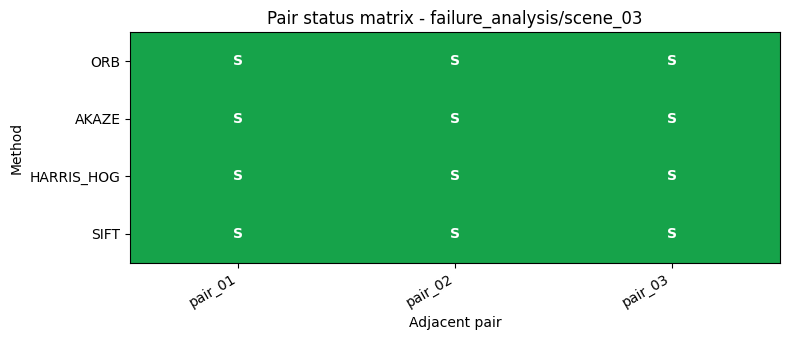

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_03_pair_metric_timeline.png


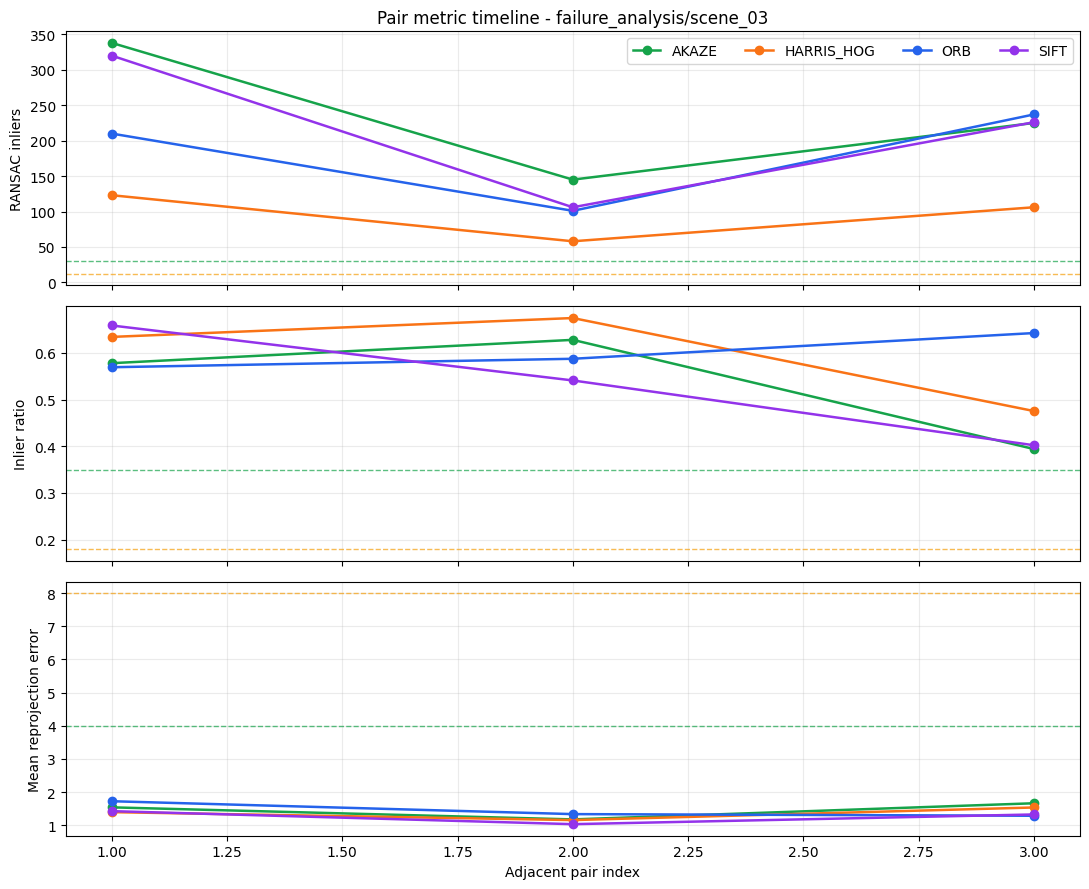

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_04_pair_status_matrix.png


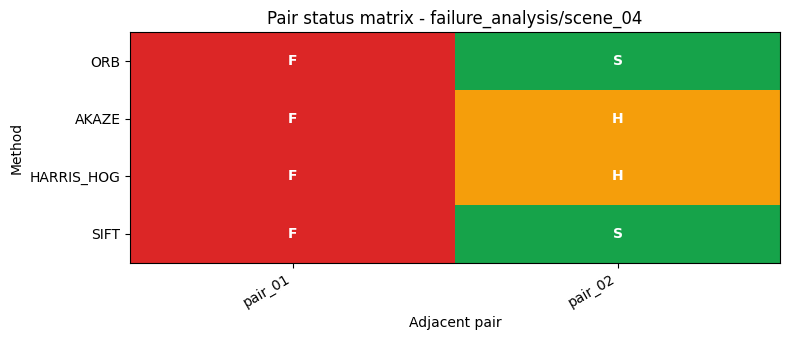

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_04_pair_metric_timeline.png


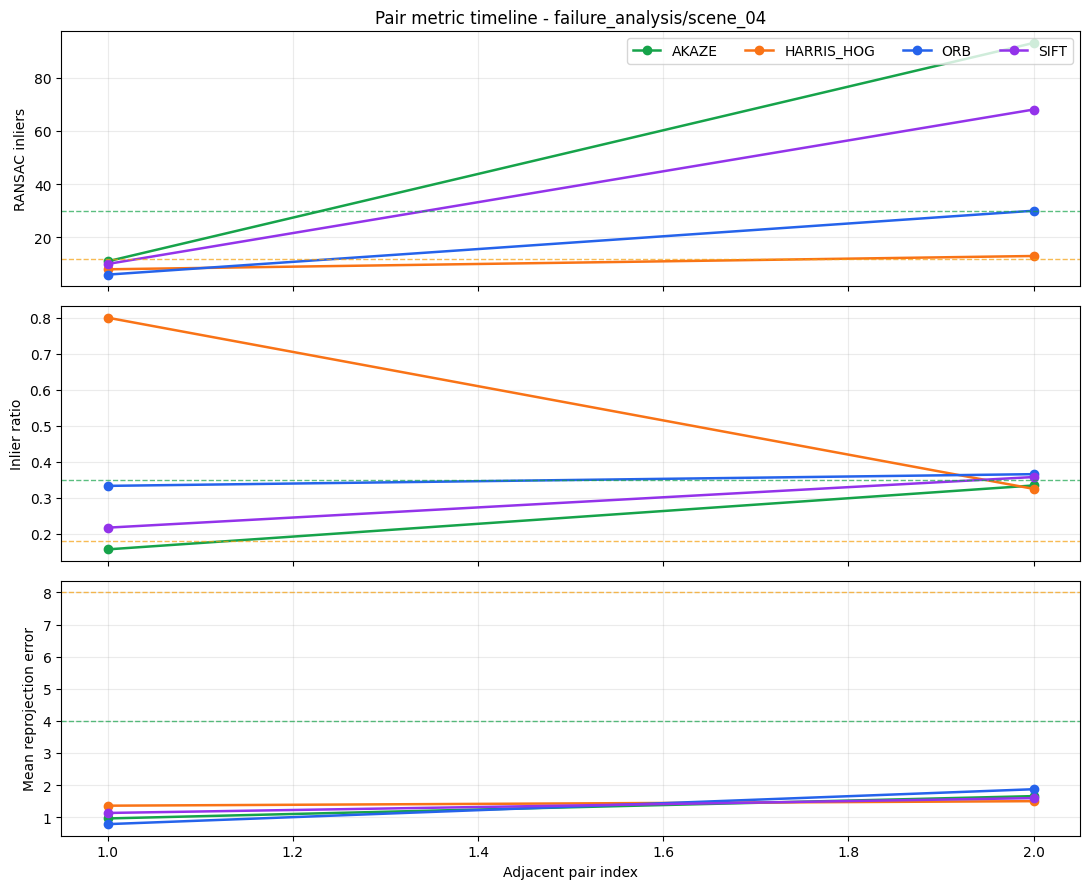

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_06_pair_status_matrix.png


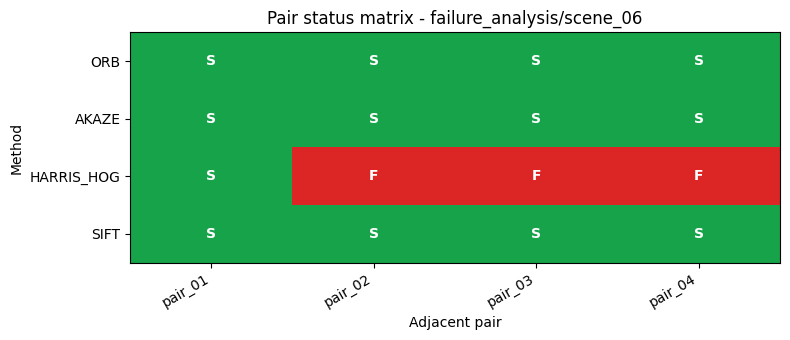

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_06_pair_metric_timeline.png


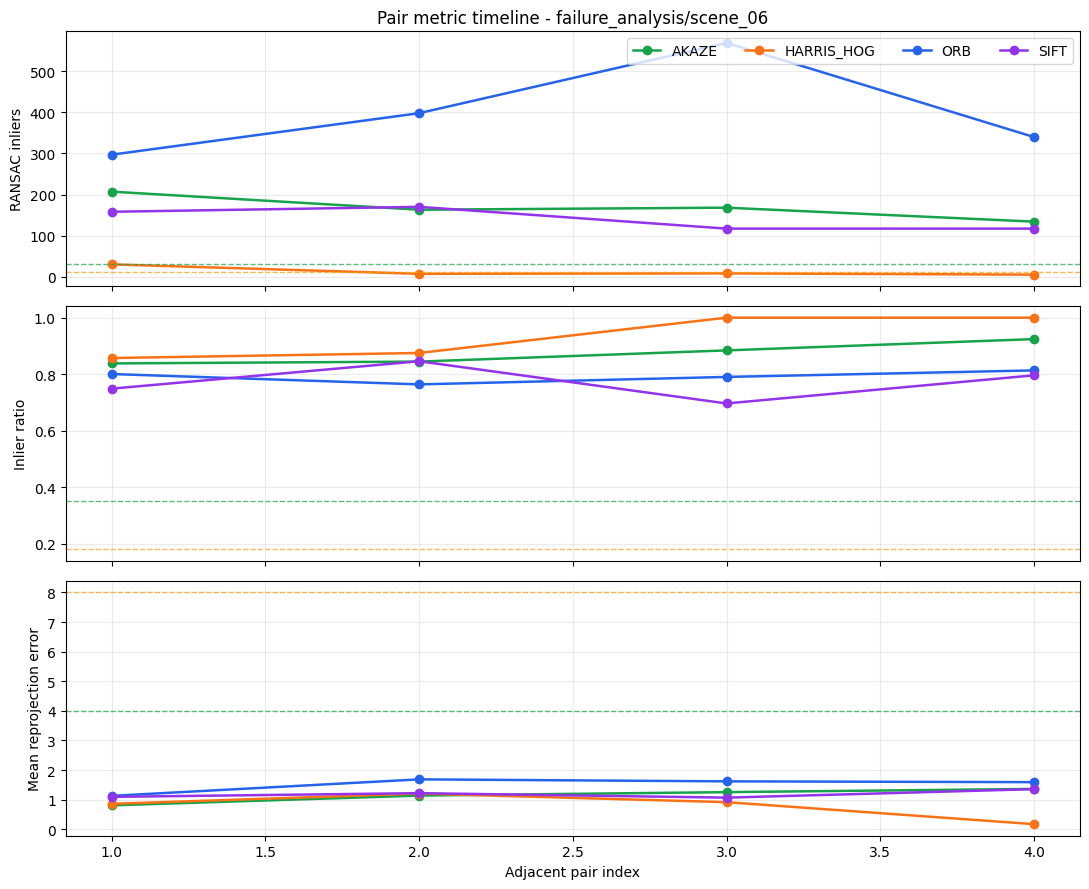

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_07_pair_status_matrix.png


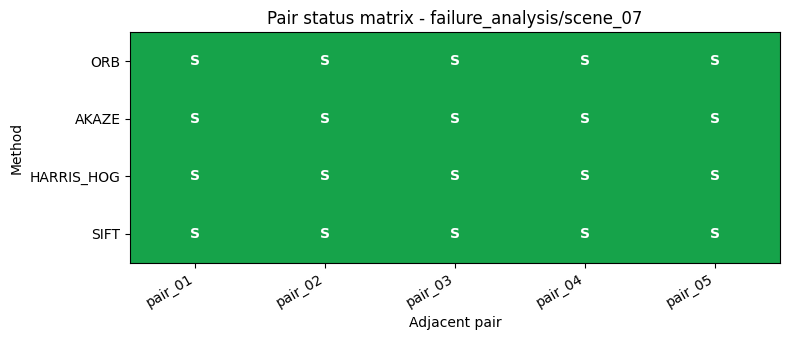

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_07_pair_metric_timeline.png


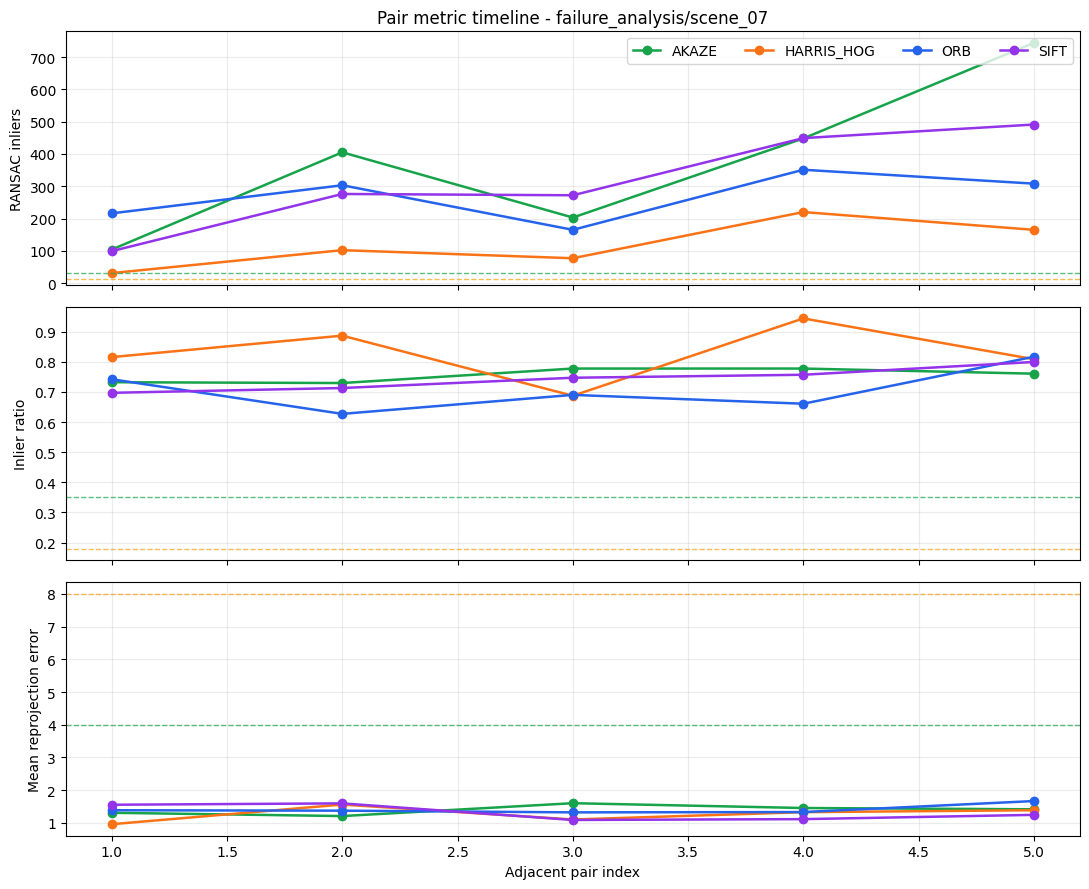

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_08_pair_status_matrix.png


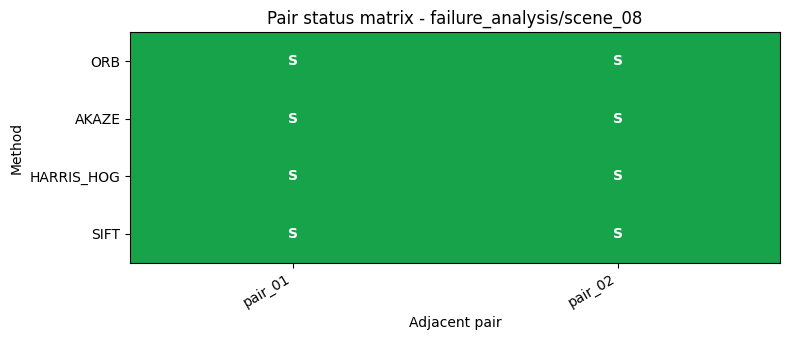

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_08_pair_metric_timeline.png


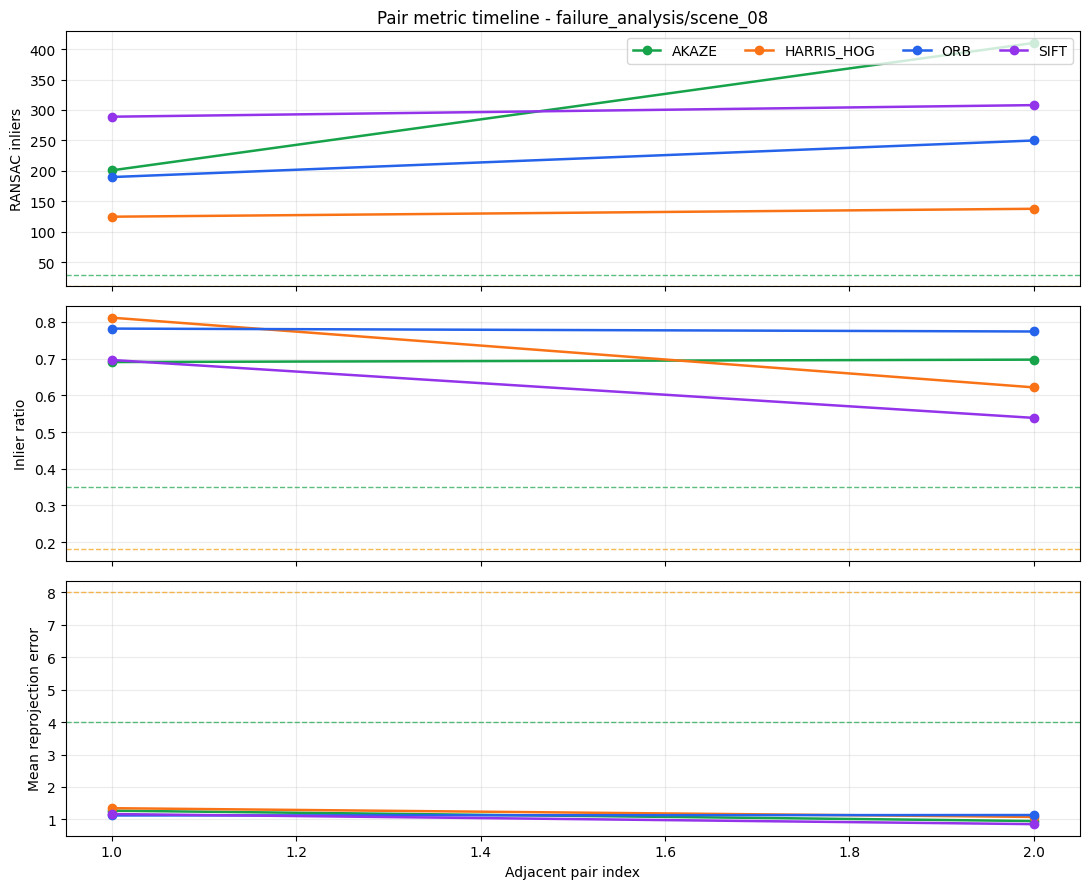

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_11_pair_status_matrix.png


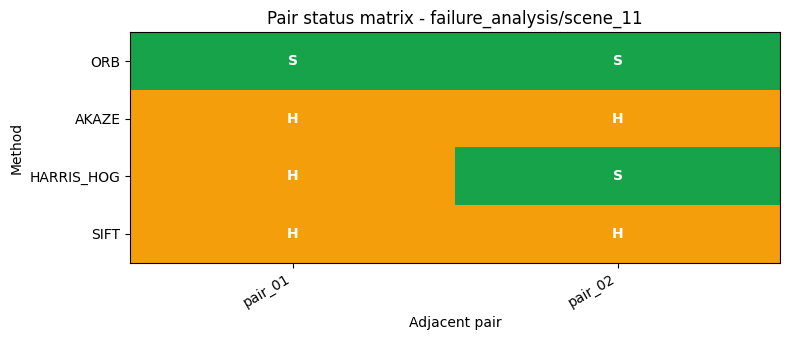

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_11_pair_metric_timeline.png


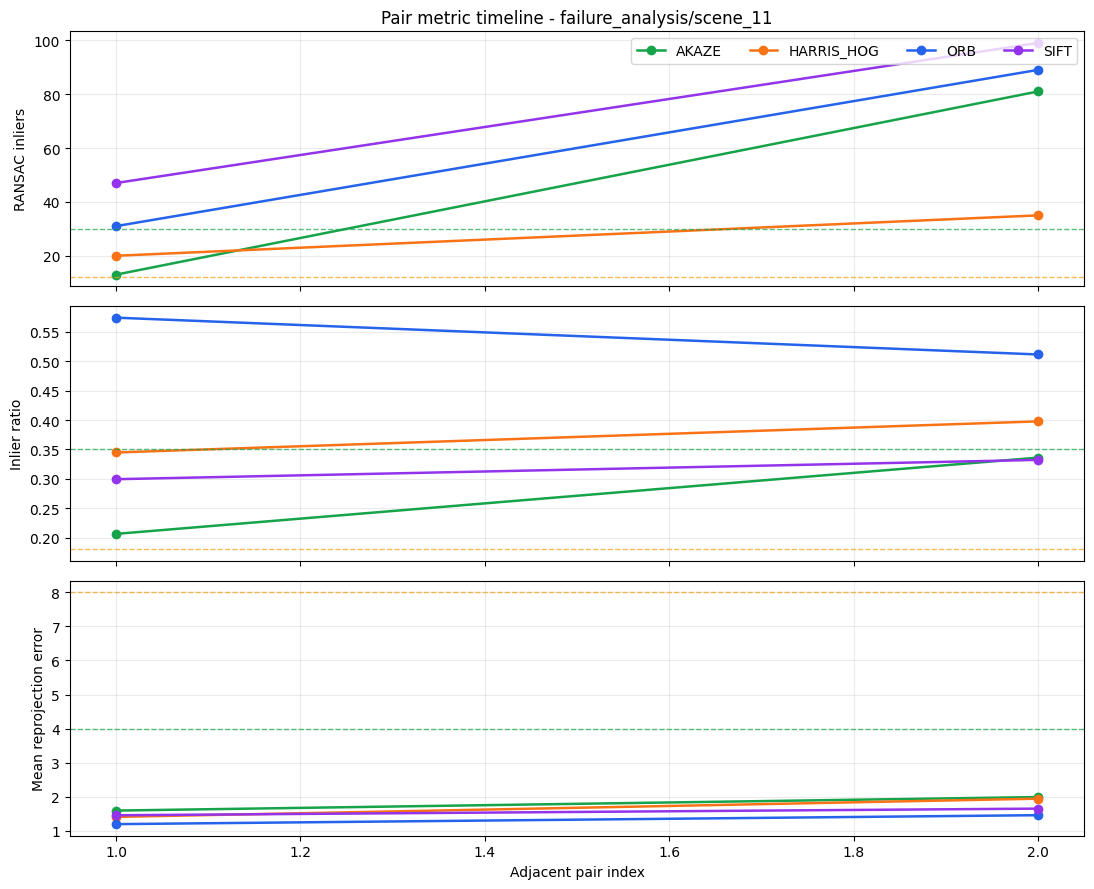

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_15_pair_status_matrix.png


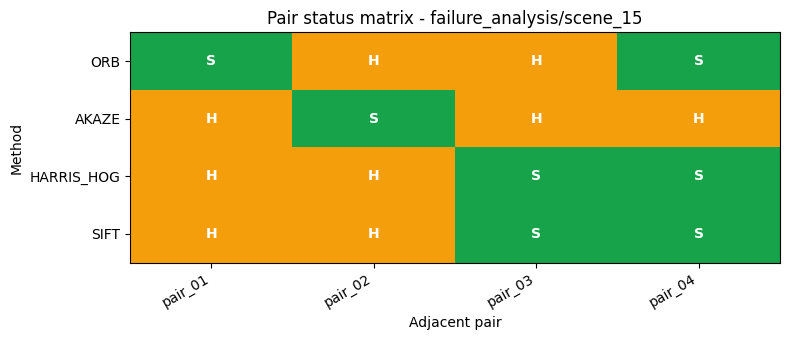

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_15_pair_metric_timeline.png


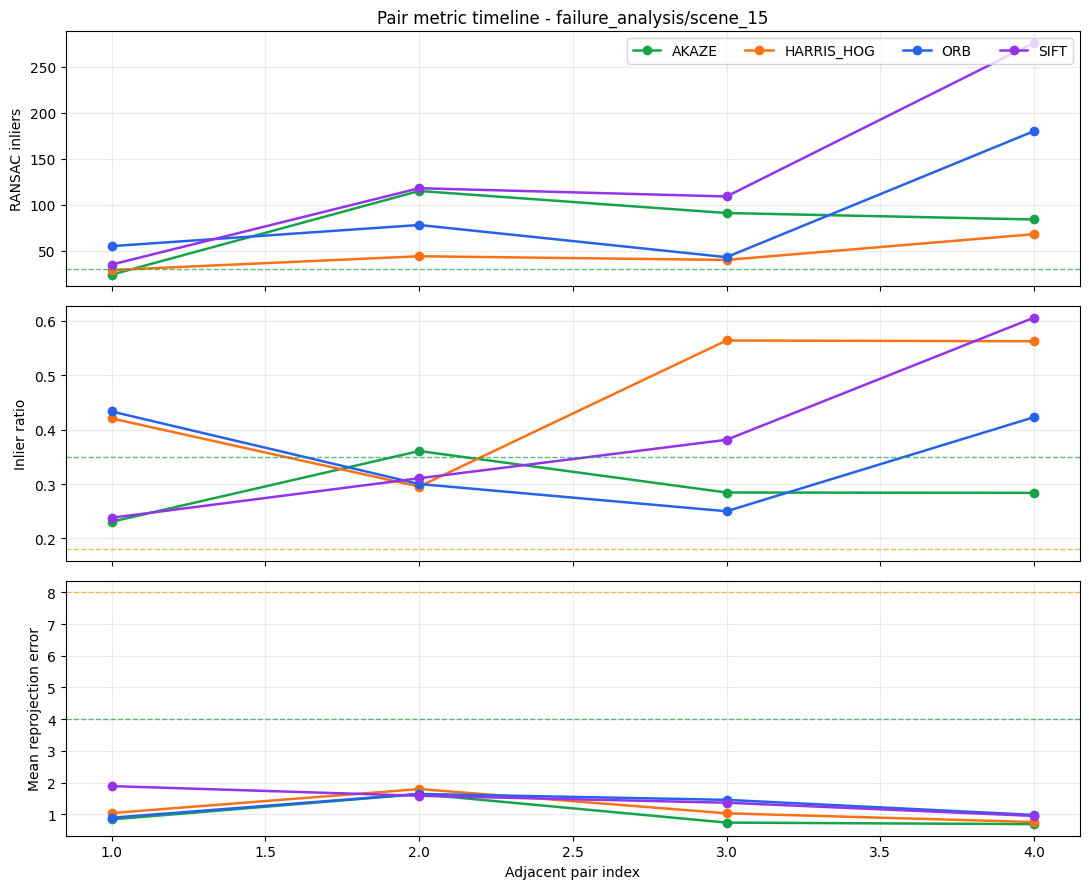

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_16_pair_status_matrix.png


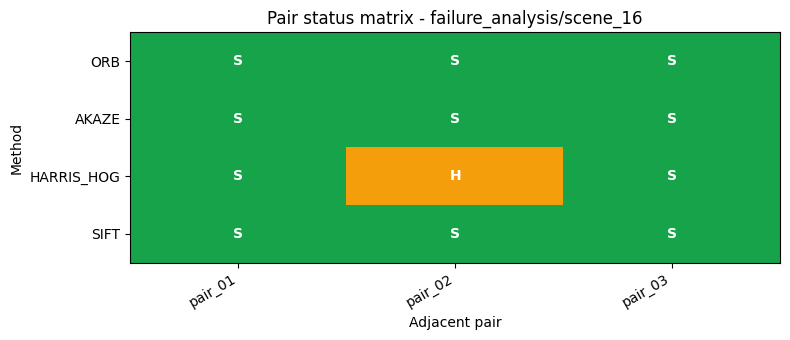

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_16_pair_metric_timeline.png


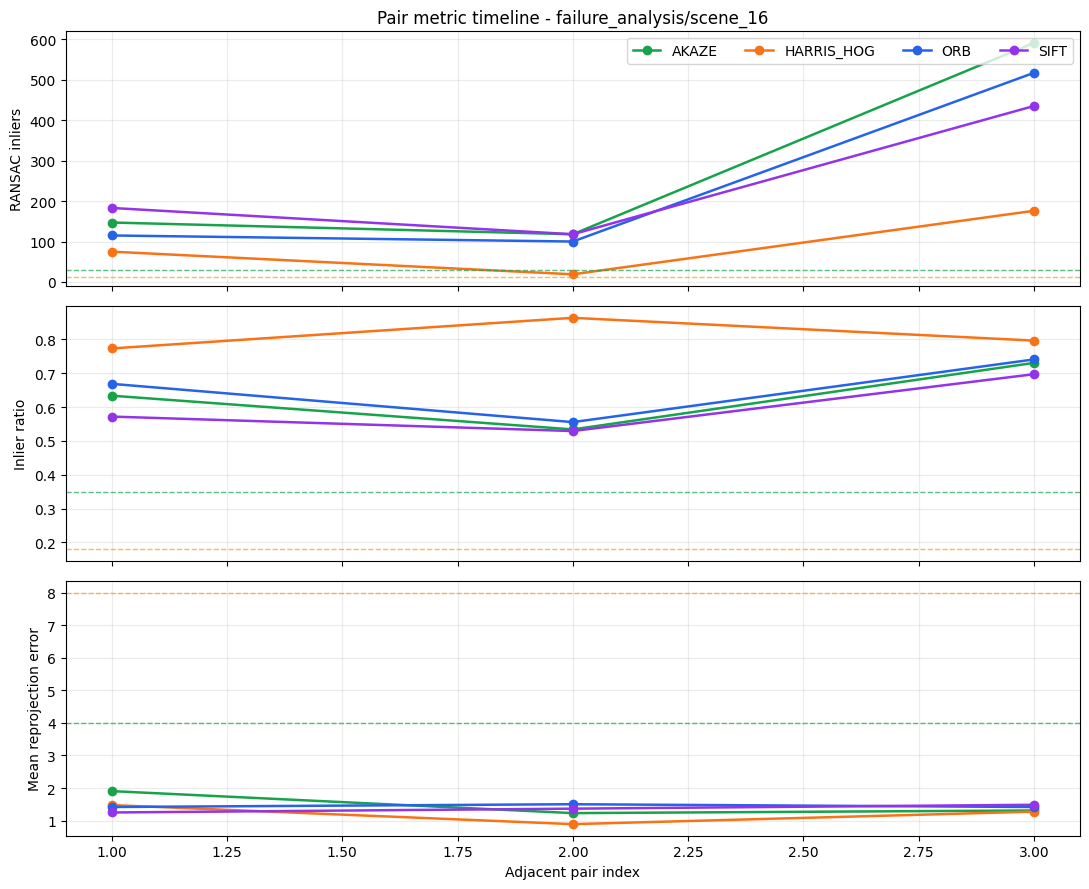

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_18_pair_status_matrix.png


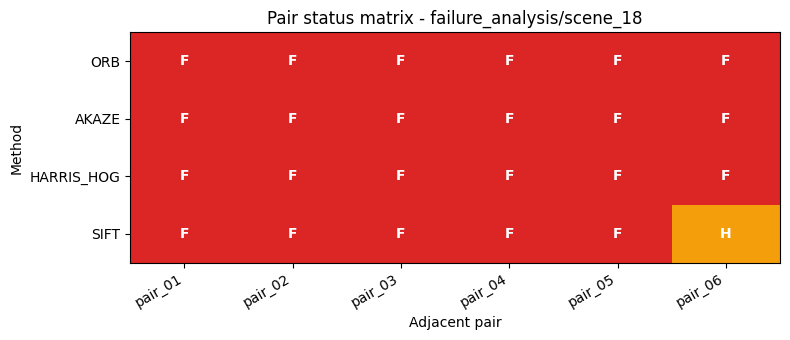

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_18_pair_metric_timeline.png


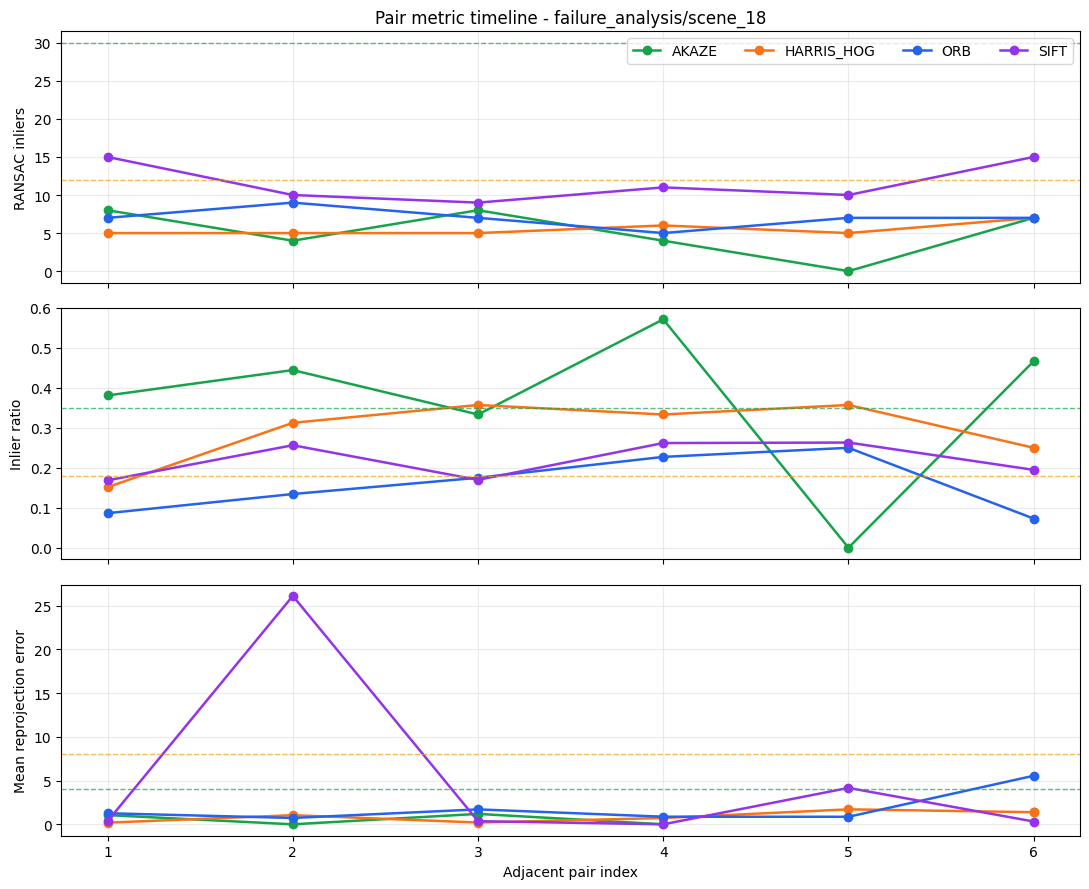

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_21_pair_status_matrix.png


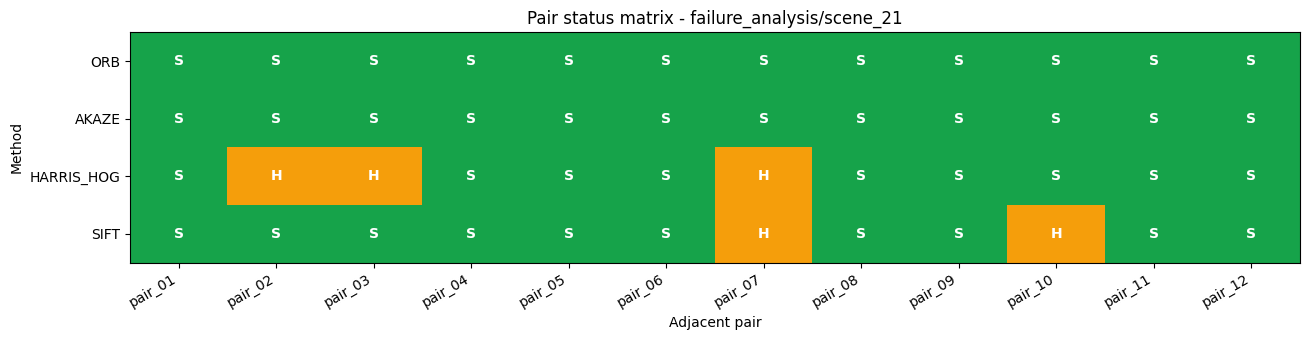

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_21_pair_metric_timeline.png


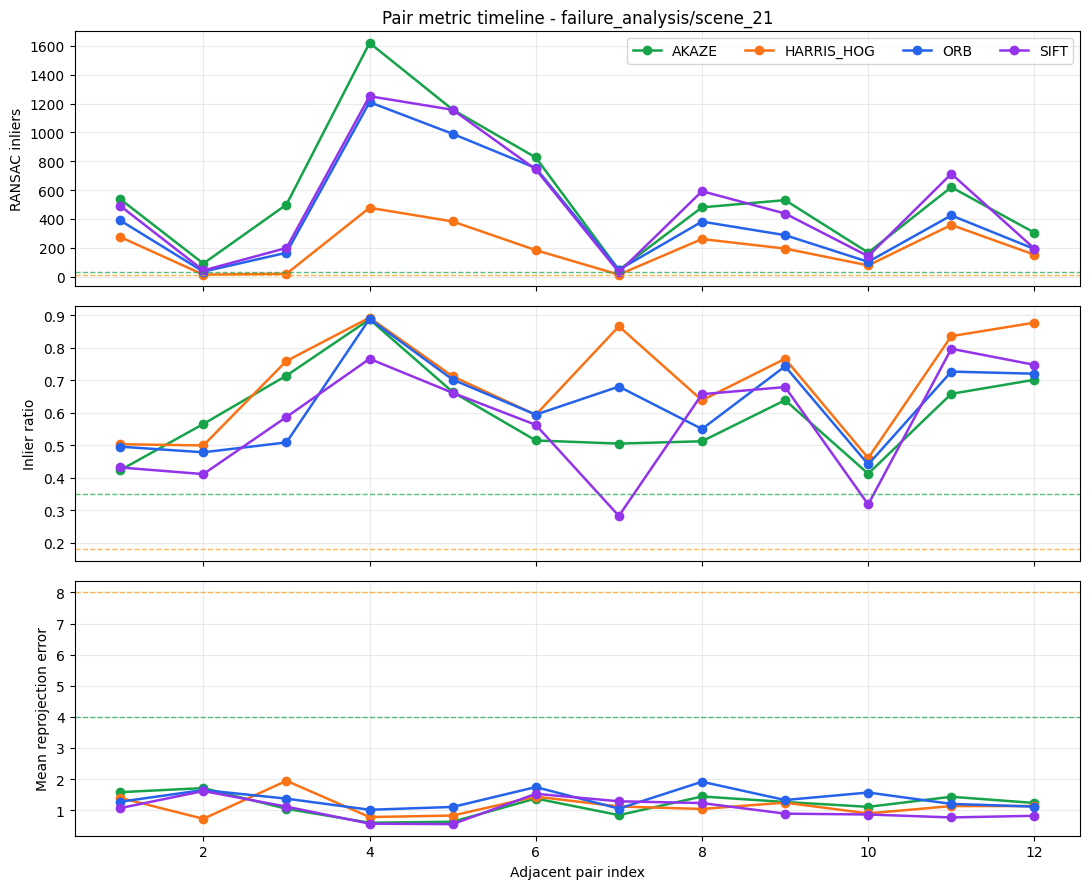

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_30_pair_status_matrix.png


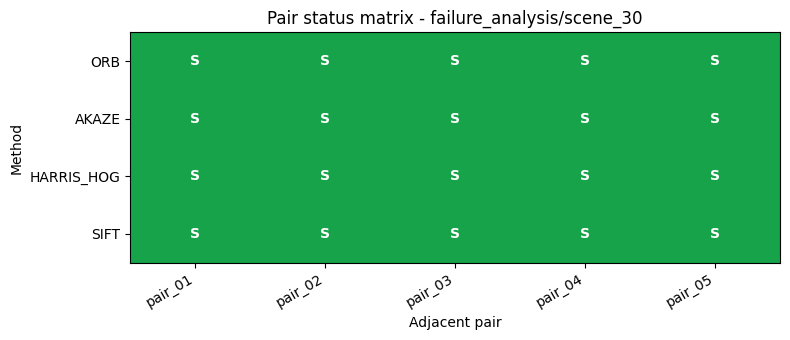

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_30_pair_metric_timeline.png


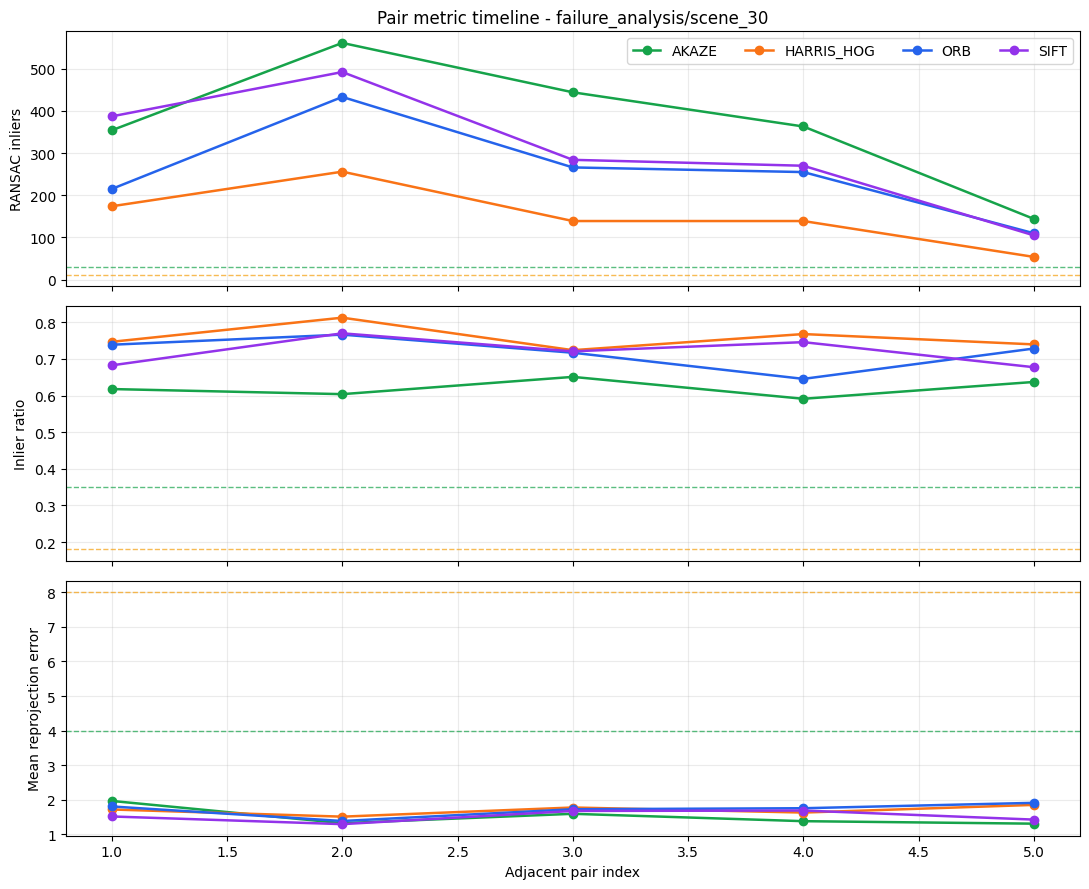

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_32_pair_status_matrix.png


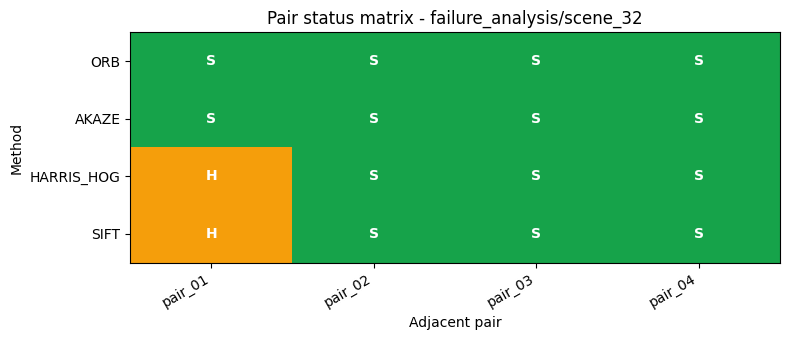

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_32_pair_metric_timeline.png


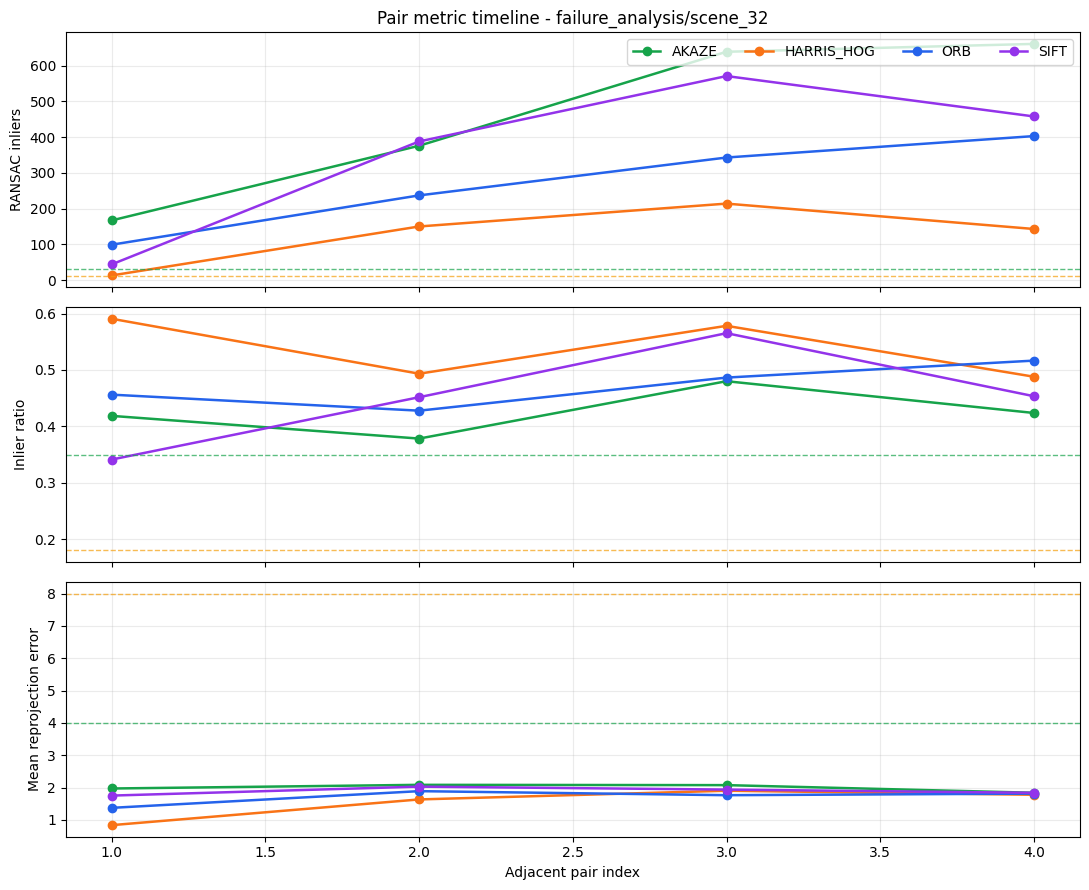

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_35_pair_status_matrix.png


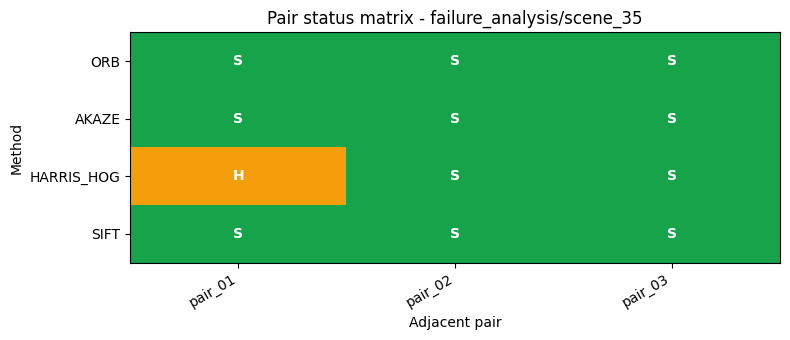

Saved plot: outputs\batch_feature_matching\plots\failure_analysis_scene_35_pair_metric_timeline.png


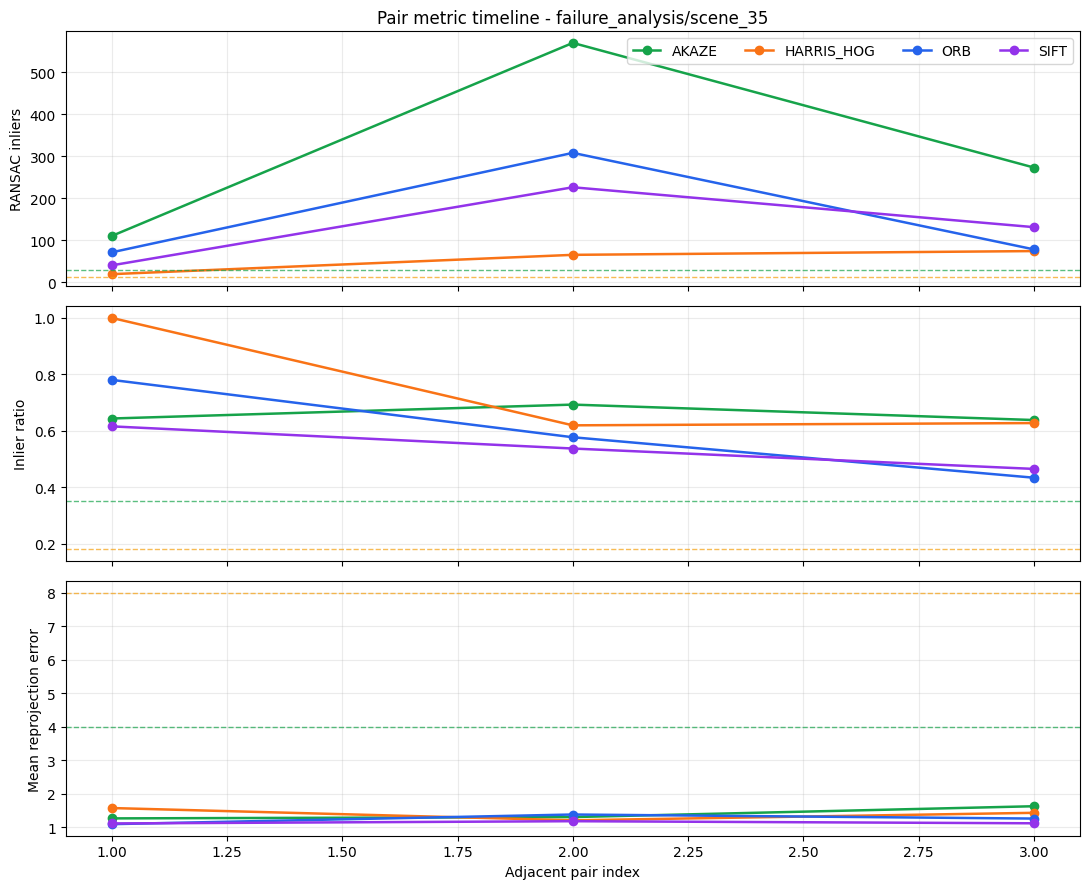

Saved plot: outputs\batch_feature_matching\plots\test_scene_36_pair_status_matrix.png


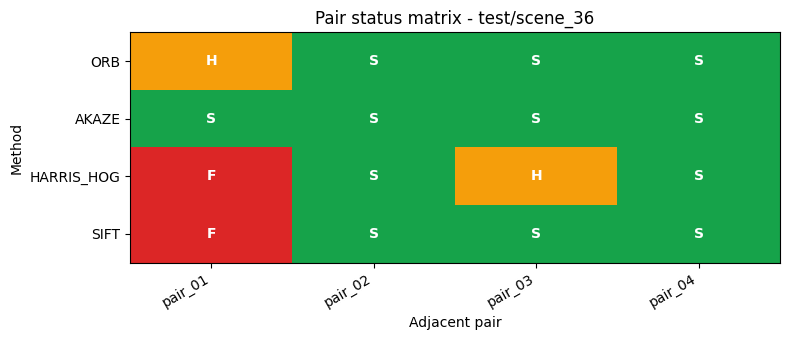

Saved plot: outputs\batch_feature_matching\plots\test_scene_36_pair_metric_timeline.png


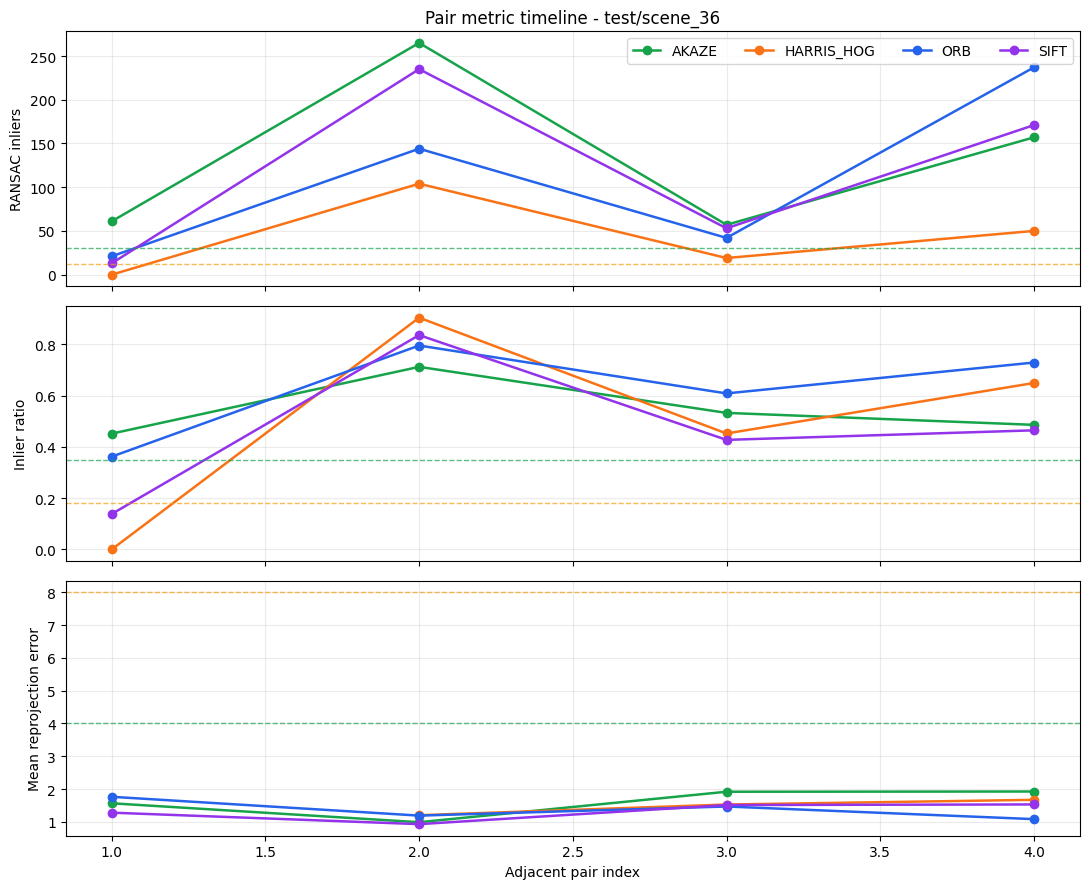

Saved scene diagnostic plot manifest: outputs\batch_feature_matching\scene_diagnostic_plot_manifest.csv


,split,scene_id,plot_type,path
0,failure_analysis,scene_03,status_matrix,outputs\batch_feature_matching\plots\failure_a...
1,failure_analysis,scene_03,metric_timeline,outputs\batch_feature_matching\plots\failure_a...
2,failure_analysis,scene_04,status_matrix,outputs\batch_feature_matching\plots\failure_a...
3,failure_analysis,scene_04,metric_timeline,outputs\batch_feature_matching\plots\failure_a...
4,failure_analysis,scene_06,status_matrix,outputs\batch_feature_matching\plots\failure_a...
5,failure_analysis,scene_06,metric_timeline,outputs\batch_feature_matching\plots\failure_a...
6,failure_analysis,scene_07,status_matrix,outputs\batch_feature_matching\plots\failure_a...
7,failure_analysis,scene_07,metric_timeline,outputs\batch_feature_matching\plots\failure_a...
8,failure_analysis,scene_08,status_matrix,outputs\batch_feature_matching\plots\failure_a...
9,failure_analysis,scene_08,metric_timeline,outputs\batch_feature_matching\plots\failure_a...


In [13]:
if HAS_MATPLOTLIB and not pair_df.empty:
    from matplotlib.colors import BoundaryNorm, ListedColormap

    def scene_diagnostic_targets() -> list[tuple[str, str]]:
        targets: list[tuple[str, str]] = []
        if RUN_FULL_BATCH:
            if PLOT_ALL_FAILURE_ANALYSIS_SCENES:
                failure_scenes = (
                    pair_df[pair_df["split"] == "failure_analysis"][["split", "scene_id"]]
                    .drop_duplicates()
                    .sort_values(["split", "scene_id"])
                )
                targets.extend([tuple(row) for row in failure_scenes.to_numpy()])

            if AUTO_DIAGNOSTIC_SCENES_PER_SPLIT > 0 and not scene_summary_df.empty:
                scene_scores = (
                    scene_summary_df.groupby(["split", "scene_id"], dropna=False)
                    .agg(
                        mean_usable_rate=("usable_rate", "mean"),
                        min_usable_rate=("usable_rate", "min"),
                        total_failures=("failure_count", "sum"),
                    )
                    .reset_index()
                )
                for split_name, split_scores in scene_scores.groupby("split"):
                    selected = split_scores.sort_values(
                        ["mean_usable_rate", "min_usable_rate", "total_failures", "scene_id"],
                        ascending=[True, True, False, True],
                    ).head(AUTO_DIAGNOSTIC_SCENES_PER_SPLIT)
                    targets.extend([(row["split"], row["scene_id"]) for _, row in selected.iterrows()])
        else:
            targets.extend((SELECTED_SPLIT, scene_id) for scene_id in SELECTED_SCENES)

        unique_targets = []
        seen = set()
        for split_name, scene_id in targets:
            key = (str(split_name), str(scene_id))
            if key not in seen:
                seen.add(key)
                unique_targets.append(key)
        return unique_targets


    def plot_scene_pair_diagnostics(split_name: str, scene_id: str) -> list[dict]:
        scene_pair_df = pair_df[(pair_df["split"] == split_name) & (pair_df["scene_id"] == scene_id)].copy()
        if scene_pair_df.empty:
            return []

        saved_rows = []
        status_matrix = scene_pair_df.pivot_table(
            index="method",
            columns="pair_id",
            values="status",
            aggfunc="first",
        ).reindex(index=METHODS)
        status_matrix = status_matrix.dropna(how="all")
        pair_columns = sorted(status_matrix.columns, key=lambda value: int(str(value).split("_")[-1]))
        status_matrix = status_matrix[pair_columns]
        score_matrix = status_matrix.apply(lambda column: column.map(STATUS_SCORE)).astype(float)

        cmap = ListedColormap([STATUS_COLORS["failure"], STATUS_COLORS["hard_valid"], STATUS_COLORS["success"]])
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

        fig, ax = plt.subplots(figsize=(max(8, 1.1 * len(pair_columns)), max(3.5, 0.45 * len(status_matrix.index) + 1.5)))
        ax.imshow(score_matrix.to_numpy(), aspect="auto", cmap=cmap, norm=norm)
        ax.set_title(f"Pair status matrix - {split_name}/{scene_id}")
        ax.set_xlabel("Adjacent pair")
        ax.set_ylabel("Method")
        ax.set_xticks(np.arange(len(pair_columns)))
        ax.set_xticklabels(pair_columns, rotation=30, ha="right")
        ax.set_yticks(np.arange(len(status_matrix.index)))
        ax.set_yticklabels(status_matrix.index)

        for y, method in enumerate(status_matrix.index):
            for x, pair_id in enumerate(pair_columns):
                status = status_matrix.loc[method, pair_id]
                label = {"success": "S", "hard_valid": "H", "failure": "F"}.get(status, "")
                ax.text(x, y, label, ha="center", va="center", color="white", fontweight="bold")

        fig.tight_layout()
        path = save_plot(fig, f"{split_name}_{scene_id}_pair_status_matrix.png")
        saved_rows.append({"split": split_name, "scene_id": scene_id, "plot_type": "status_matrix", "path": str(path.relative_to(PROJECT_ROOT))})
        plt.show()
        plt.close(fig)

        colors = method_color_map()
        fig, axes = plt.subplots(3, 1, figsize=(max(11, 0.75 * len(pair_columns)), 9), sharex=True)
        metrics = [
            ("inliers", "RANSAC inliers"),
            ("inlier_ratio", "Inlier ratio"),
            ("reprojection_error_mean", "Mean reprojection error"),
        ]

        for ax, (column, label) in zip(axes, metrics):
            for method, method_df in scene_pair_df.groupby("method"):
                method_df = method_df.sort_values("pair_index")
                ax.plot(
                    method_df["pair_index"],
                    method_df[column],
                    marker="o",
                    linewidth=1.8,
                    label=method,
                    color=colors.get(method),
                )
            ax.set_ylabel(label)
            ax.grid(True, alpha=0.25)
            if column == "reprojection_error_mean":
                ax.axhline(SUCCESS_MAX_REPROJ_ERROR, color=STATUS_COLORS["success"], linestyle="--", linewidth=1.0, alpha=0.7)
                ax.axhline(HARD_MAX_REPROJ_ERROR, color=STATUS_COLORS["hard_valid"], linestyle="--", linewidth=1.0, alpha=0.7)
            elif column == "inlier_ratio":
                ax.axhline(SUCCESS_MIN_INLIER_RATIO, color=STATUS_COLORS["success"], linestyle="--", linewidth=1.0, alpha=0.7)
                ax.axhline(HARD_MIN_INLIER_RATIO, color=STATUS_COLORS["hard_valid"], linestyle="--", linewidth=1.0, alpha=0.7)
            elif column == "inliers":
                ax.axhline(SUCCESS_MIN_INLIERS, color=STATUS_COLORS["success"], linestyle="--", linewidth=1.0, alpha=0.7)
                ax.axhline(HARD_MIN_INLIERS, color=STATUS_COLORS["hard_valid"], linestyle="--", linewidth=1.0, alpha=0.7)

        axes[-1].set_xlabel("Adjacent pair index")
        axes[0].set_title(f"Pair metric timeline - {split_name}/{scene_id}")
        axes[0].legend(loc="upper right", ncols=min(len(METHODS), 4))
        fig.tight_layout()
        path = save_plot(fig, f"{split_name}_{scene_id}_pair_metric_timeline.png")
        saved_rows.append({"split": split_name, "scene_id": scene_id, "plot_type": "metric_timeline", "path": str(path.relative_to(PROJECT_ROOT))})
        plt.show()
        plt.close(fig)
        return saved_rows


    diagnostic_rows = []
    for split_name, scene_id in scene_diagnostic_targets():
        diagnostic_rows.extend(plot_scene_pair_diagnostics(split_name, scene_id))

    scene_diagnostic_manifest_df = pd.DataFrame(diagnostic_rows)
    scene_diagnostic_manifest_path = OUTPUT_ROOT / "scene_diagnostic_plot_manifest.csv"
    scene_diagnostic_manifest_df.to_csv(scene_diagnostic_manifest_path, index=False, encoding="utf-8-sig")
    print(f"Saved scene diagnostic plot manifest: {scene_diagnostic_manifest_path.relative_to(PROJECT_ROOT)}")
    display(scene_diagnostic_manifest_df)




C:\Users\PC\AppData\Local\Temp\ipykernel_24184\2455451128.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_24184\2455451128.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_24184\2455451128.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_24184\2455451128.py:24: Ma

Saved plot: outputs\batch_feature_matching\plots\metric_distributions_by_method.png


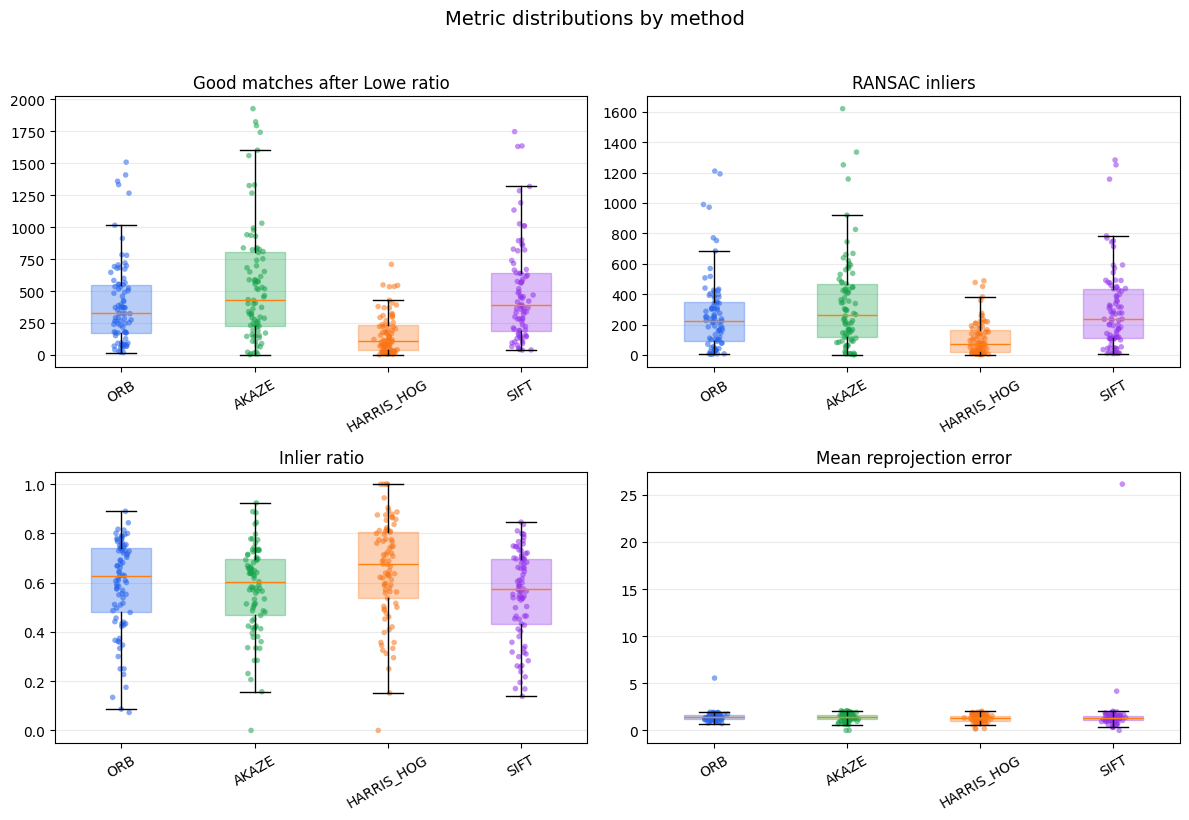

In [14]:
if HAS_MATPLOTLIB and not pair_df.empty:
    metric_specs = [
        ("good_matches", "Good matches after Lowe ratio"),
        ("inliers", "RANSAC inliers"),
        ("inlier_ratio", "Inlier ratio"),
        ("reprojection_error_mean", "Mean reprojection error"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()
    rng = np.random.default_rng(15)
    colors = method_color_map()

    for ax, (column, label) in zip(axes, metric_specs):
        data = []
        labels = []
        for method in METHODS:
            values = finite_series(pair_df[pair_df["method"] == method], column)
            if len(values):
                data.append(values.to_numpy(dtype=float))
                labels.append(method)

        if data:
            box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
            for patch, method in zip(box["boxes"], labels):
                patch.set_facecolor(colors.get(method, "#64748b"))
                patch.set_alpha(0.32)
                patch.set_edgecolor(colors.get(method, "#64748b"))

            for x_pos, (method, values) in enumerate(zip(labels, data), start=1):
                jitter = rng.normal(0.0, 0.035, size=len(values))
                ax.scatter(
                    np.full(len(values), x_pos) + jitter,
                    values,
                    s=16,
                    alpha=0.55,
                    color=colors.get(method, "#64748b"),
                    edgecolors="none",
                )

        ax.set_title(label)
        ax.tick_params(axis="x", rotation=30)
        ax.grid(True, axis="y", alpha=0.25)

    fig.suptitle("Metric distributions by method", y=1.02, fontsize=14)
    fig.tight_layout()
    save_plot(fig, "metric_distributions_by_method.png")
    plt.show()


Saved weak-pair summary: outputs\batch_feature_matching\weak_pair_summary.csv


,split,scene_id,pair_id,pair_index,methods,success_count,hard_valid_count,failure_count,median_good_matches,median_inliers,median_inlier_ratio,median_reprojection_error,category,difficulty,success_rate,hard_valid_rate,failure_rate,usable_rate
28,failure_analysis,scene_18,pair_04,4,4,0,0,4,20.0,5.5,0.297619,0.359932,failure,hard,0.00,0.00,1.00,0.00
29,failure_analysis,scene_18,pair_05,5,4,0,0,4,21.0,6.0,0.256579,1.711190,failure,hard,0.00,0.00,1.00,0.00
26,failure_analysis,scene_18,pair_02,2,4,0,0,4,27.5,7.0,0.284455,0.884884,failure,hard,0.00,0.00,1.00,0.00
27,failure_analysis,scene_18,pair_03,3,4,0,0,4,32.0,7.5,0.254167,0.773833,failure,hard,0.00,0.00,1.00,0.00
25,failure_analysis,scene_18,pair_01,1,4,0,0,4,57.0,7.5,0.160027,0.704316,failure,hard,0.00,0.00,1.00,0.00
3,failure_analysis,scene_04,pair_01,1,4,0,0,4,32.0,9.0,0.275362,1.044912,failure,hard,0.00,0.00,1.00,0.00
30,failure_analysis,scene_18,pair_06,6,4,0,1,3,52.5,7.0,0.222403,1.379222,failure,hard,0.00,0.25,0.75,0.25
74,test,scene_36,pair_01,1,4,1,1,2,76.0,17.0,0.250183,1.564147,hard_valid,medium,0.25,0.25,0.50,0.50
70,test,scene_33,pair_02,2,4,2,1,1,115.5,38.5,0.387402,1.376080,success,medium,0.50,0.25,0.25,0.75
8,failure_analysis,scene_06,pair_04,4,4,3,0,1,146.0,125.5,0.868768,1.357616,hard_valid,hard,0.75,0.00,0.25,0.75


Saved plot: outputs\batch_feature_matching\plots\failure_analysis_pair_status_overview.png


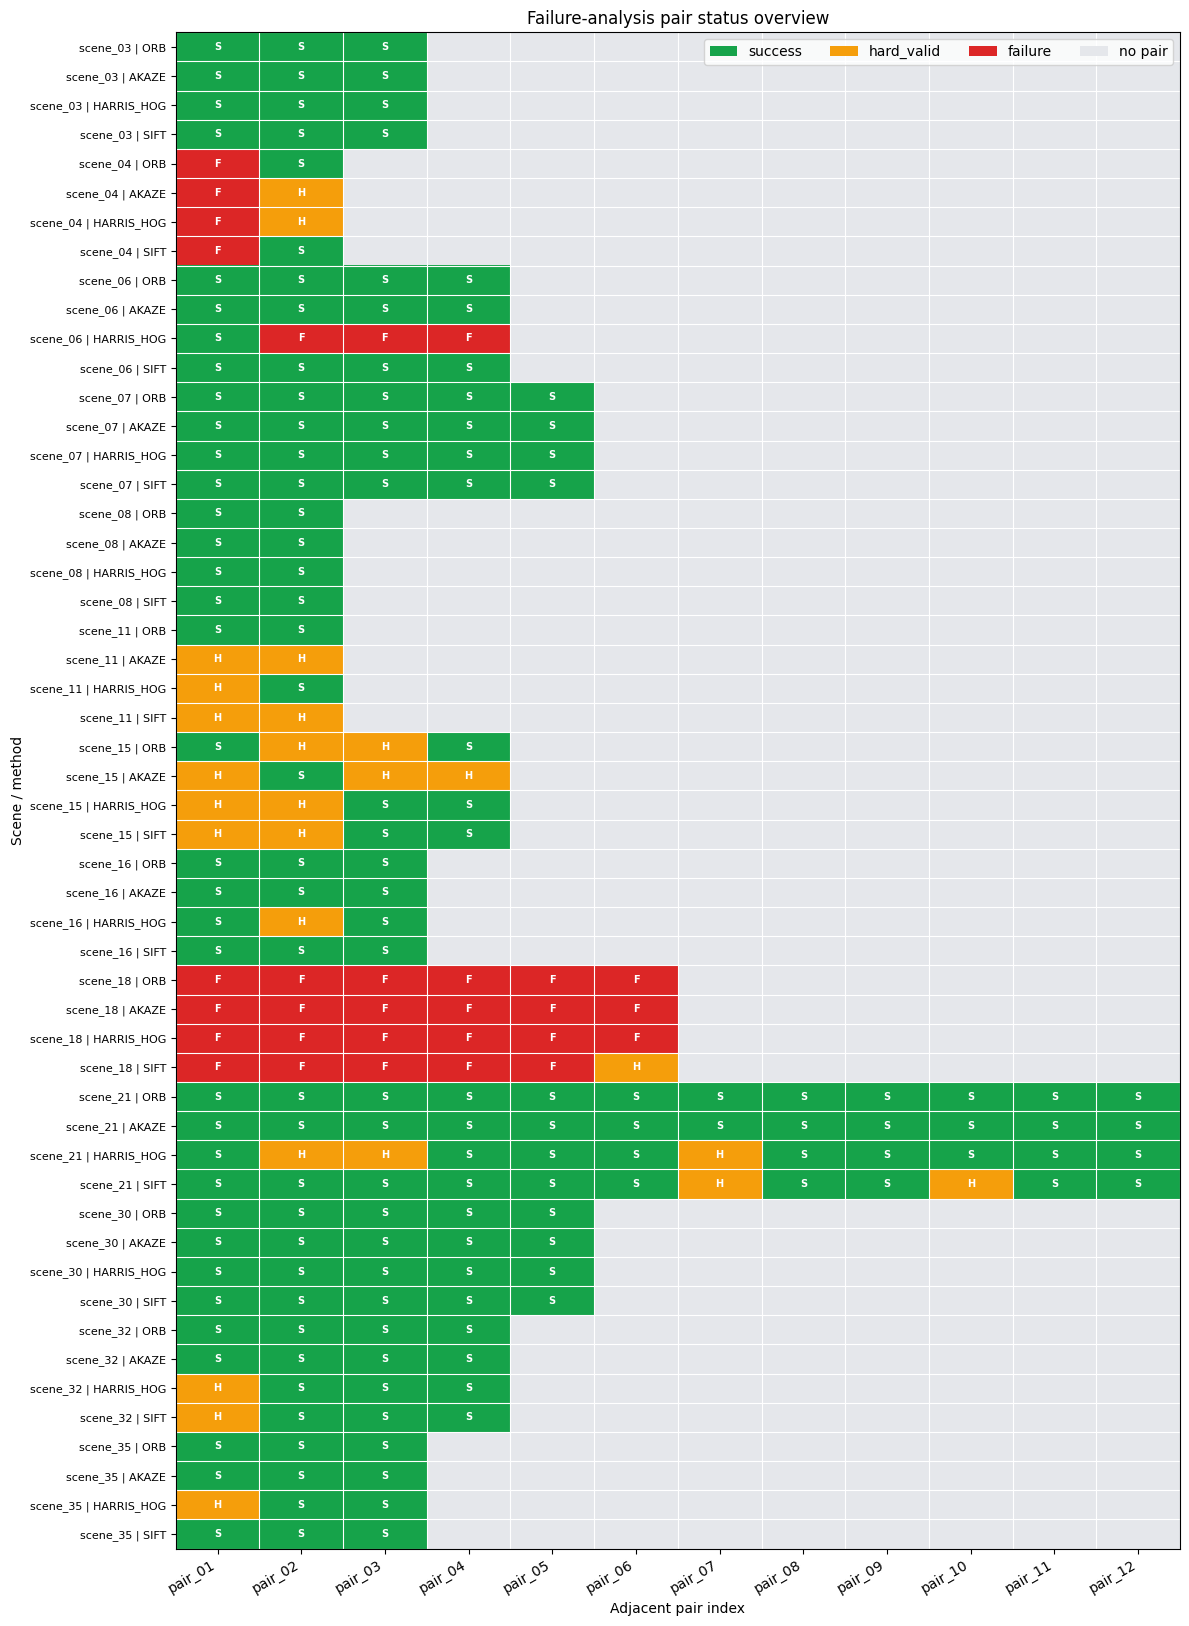

Saved plot: outputs\batch_feature_matching\plots\weakest_adjacent_pairs_status_stack.png


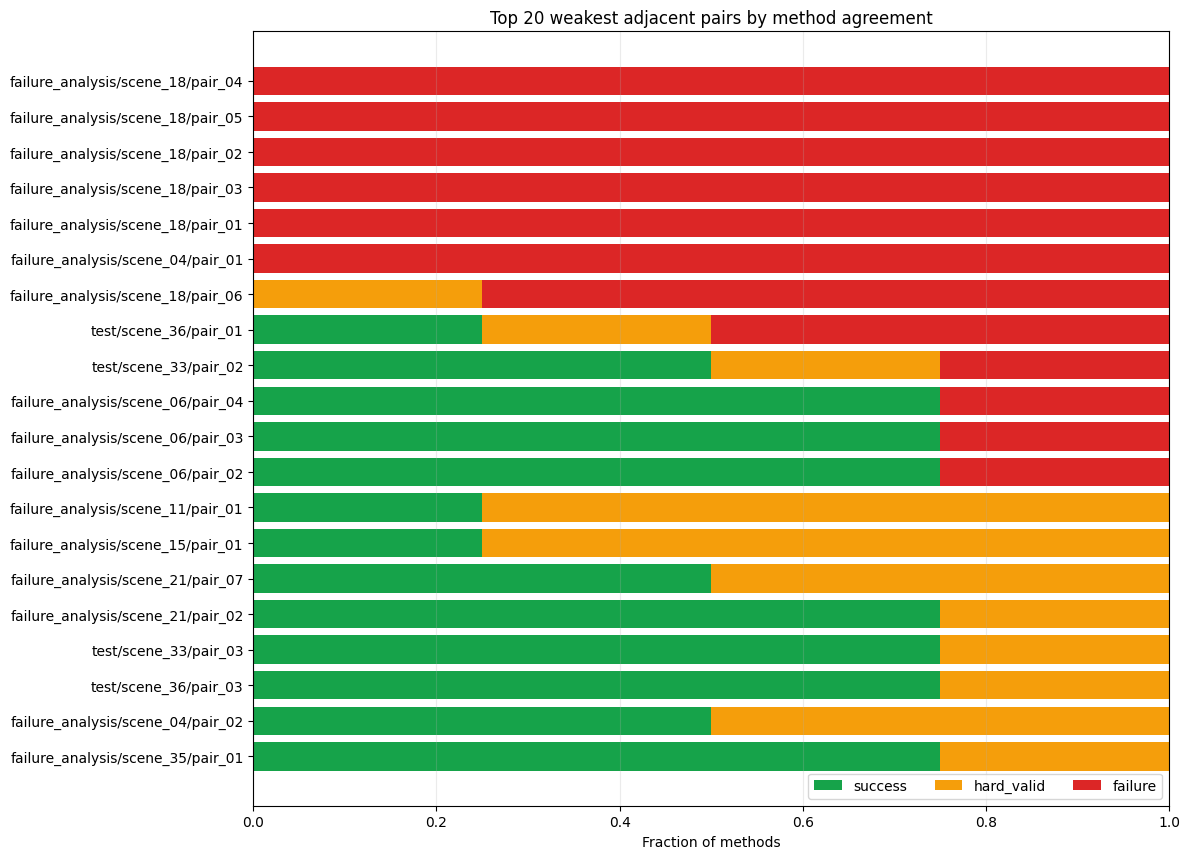

Saved plot: outputs\batch_feature_matching\plots\method_quality_bubble_by_split.png


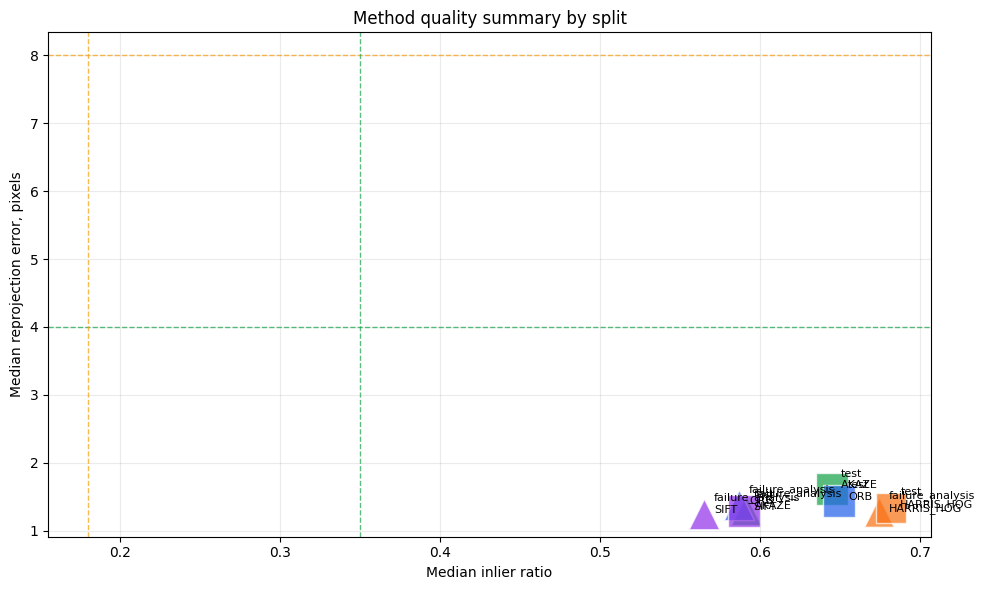

In [15]:
if not pair_df.empty:
    weak_pair_summary_df = (
        pair_df.assign(
            success_flag=(pair_df["status"] == "success").astype(int),
            hard_valid_flag=(pair_df["status"] == "hard_valid").astype(int),
            failure_flag=(pair_df["status"] == "failure").astype(int),
        )
        .groupby(["split", "scene_id", "pair_id", "pair_index"], dropna=False)
        .agg(
            methods=("method", "nunique"),
            success_count=("success_flag", "sum"),
            hard_valid_count=("hard_valid_flag", "sum"),
            failure_count=("failure_flag", "sum"),
            median_good_matches=("good_matches", "median"),
            median_inliers=("inliers", "median"),
            median_inlier_ratio=("inlier_ratio", "median"),
            median_reprojection_error=("reprojection_error_mean", "median"),
            category=("category", "first"),
            difficulty=("difficulty", "first"),
        )
        .reset_index()
    )
    weak_pair_summary_df["success_rate"] = weak_pair_summary_df["success_count"] / weak_pair_summary_df["methods"].clip(lower=1)
    weak_pair_summary_df["hard_valid_rate"] = weak_pair_summary_df["hard_valid_count"] / weak_pair_summary_df["methods"].clip(lower=1)
    weak_pair_summary_df["failure_rate"] = weak_pair_summary_df["failure_count"] / weak_pair_summary_df["methods"].clip(lower=1)
    weak_pair_summary_df["usable_rate"] = (weak_pair_summary_df["success_count"] + weak_pair_summary_df["hard_valid_count"]) / weak_pair_summary_df["methods"].clip(lower=1)

    weak_pair_summary_path = OUTPUT_ROOT / "weak_pair_summary.csv"
    weak_pair_summary_df.to_csv(weak_pair_summary_path, index=False, encoding="utf-8-sig")
    print(f"Saved weak-pair summary: {weak_pair_summary_path.relative_to(PROJECT_ROOT)}")
    display(
        weak_pair_summary_df.sort_values(
            ["failure_rate", "median_inliers", "median_reprojection_error"],
            ascending=[False, True, False],
        ).head(TOP_WEAK_PAIR_COUNT)
    )

if HAS_MATPLOTLIB and not pair_df.empty:
    failure_df = pair_df[pair_df["split"] == "failure_analysis"].copy()
    if not failure_df.empty:
        from matplotlib.colors import BoundaryNorm, ListedColormap
        from matplotlib.patches import Patch

        scenes = sorted(failure_df["scene_id"].unique(), key=lambda value: int(str(value).split("_")[-1]))
        row_keys = [(scene_id, method) for scene_id in scenes for method in METHODS]
        max_pair_index = int(failure_df["pair_index"].max())
        matrix = np.full((len(row_keys), max_pair_index), np.nan, dtype=float)

        for y, (scene_id, method) in enumerate(row_keys):
            rows = failure_df[(failure_df["scene_id"] == scene_id) & (failure_df["method"] == method)]
            for _, row in rows.iterrows():
                matrix[y, int(row["pair_index"]) - 1] = STATUS_SCORE.get(row["status"], np.nan)

        cmap = ListedColormap([STATUS_COLORS["failure"], STATUS_COLORS["hard_valid"], STATUS_COLORS["success"]])
        cmap.set_bad("#e5e7eb")
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
        masked_matrix = np.ma.masked_invalid(matrix)

        fig_height = max(7.0, 0.28 * len(row_keys) + 1.8)
        fig, ax = plt.subplots(figsize=(12, fig_height))
        ax.imshow(masked_matrix, aspect="auto", cmap=cmap, norm=norm)
        ax.set_title("Failure-analysis pair status overview")
        ax.set_xlabel("Adjacent pair index")
        ax.set_ylabel("Scene / method")
        ax.set_xticks(np.arange(max_pair_index))
        ax.set_xticklabels([f"pair_{index + 1:02d}" for index in range(max_pair_index)], rotation=30, ha="right")
        ax.set_yticks(np.arange(len(row_keys)))
        ax.set_yticklabels([f"{scene_id} | {method}" for scene_id, method in row_keys], fontsize=8)
        ax.set_xticks(np.arange(-0.5, max_pair_index, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(row_keys), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.8)
        ax.tick_params(which="minor", bottom=False, left=False)

        for y in range(matrix.shape[0]):
            for x in range(matrix.shape[1]):
                value = matrix[y, x]
                if np.isfinite(value):
                    label = {2: "S", 1: "H", 0: "F"}.get(int(value), "")
                    ax.text(x, y, label, ha="center", va="center", color="white", fontsize=7, fontweight="bold")

        legend_handles = [
            Patch(facecolor=STATUS_COLORS["success"], label="success"),
            Patch(facecolor=STATUS_COLORS["hard_valid"], label="hard_valid"),
            Patch(facecolor=STATUS_COLORS["failure"], label="failure"),
            Patch(facecolor="#e5e7eb", label="no pair"),
        ]
        ax.legend(handles=legend_handles, loc="upper right", ncols=4)
        fig.tight_layout()
        save_plot(fig, "failure_analysis_pair_status_overview.png")
        plt.show()
        plt.close(fig)

    if "weak_pair_summary_df" in globals() and not weak_pair_summary_df.empty:
        top_weak = weak_pair_summary_df.sort_values(
            ["failure_rate", "usable_rate", "median_inliers", "median_reprojection_error"],
            ascending=[False, True, True, False],
        ).head(TOP_WEAK_PAIR_COUNT).copy()
        top_weak["label"] = top_weak["split"] + "/" + top_weak["scene_id"] + "/" + top_weak["pair_id"]
        top_weak = top_weak.iloc[::-1]

        fig, ax = plt.subplots(figsize=(12, max(5, 0.36 * len(top_weak) + 1.5)))
        y = np.arange(len(top_weak))
        ax.barh(y, top_weak["success_rate"], color=STATUS_COLORS["success"], label="success")
        ax.barh(y, top_weak["hard_valid_rate"], left=top_weak["success_rate"], color=STATUS_COLORS["hard_valid"], label="hard_valid")
        ax.barh(y, top_weak["failure_rate"], left=top_weak["success_rate"] + top_weak["hard_valid_rate"], color=STATUS_COLORS["failure"], label="failure")
        ax.set_title(f"Top {len(top_weak)} weakest adjacent pairs by method agreement")
        ax.set_xlabel("Fraction of methods")
        ax.set_yticks(y)
        ax.set_yticklabels(top_weak["label"])
        ax.set_xlim(0, 1.0)
        ax.grid(axis="x", alpha=0.25)
        ax.legend(loc="lower right", ncols=3)
        fig.tight_layout()
        save_plot(fig, "weakest_adjacent_pairs_status_stack.png")
        plt.show()
        plt.close(fig)
        plt.close(fig)

    if not method_summary_df.empty:
        colors = method_color_map()
        marker_map = {"development": "o", "test": "s", "failure_analysis": "^"}
        fig, ax = plt.subplots(figsize=(10, 6))
        for _, row in method_summary_df.iterrows():
            ax.scatter(
                row["median_inlier_ratio"],
                row["median_reprojection_error"],
                s=160 + 360 * float(row["usable_rate"]),
                color=colors.get(row["method"], "#64748b"),
                marker=marker_map.get(row["split"], "o"),
                alpha=0.72,
                edgecolor="white",
                linewidth=1.0,
            )
            ax.text(
                row["median_inlier_ratio"] + 0.006,
                row["median_reprojection_error"] + 0.015,
                f"{row['split']}\n{row['method']}",
                fontsize=8,
            )
        ax.axhline(SUCCESS_MAX_REPROJ_ERROR, color=STATUS_COLORS["success"], linestyle="--", linewidth=1.0, alpha=0.7)
        ax.axhline(HARD_MAX_REPROJ_ERROR, color=STATUS_COLORS["hard_valid"], linestyle="--", linewidth=1.0, alpha=0.7)
        ax.axvline(SUCCESS_MIN_INLIER_RATIO, color=STATUS_COLORS["success"], linestyle="--", linewidth=1.0, alpha=0.7)
        ax.axvline(HARD_MIN_INLIER_RATIO, color=STATUS_COLORS["hard_valid"], linestyle="--", linewidth=1.0, alpha=0.7)
        ax.set_title("Method quality summary by split")
        ax.set_xlabel("Median inlier ratio")
        ax.set_ylabel("Median reprojection error, pixels")
        ax.grid(True, alpha=0.25)
        fig.tight_layout()
        save_plot(fig, "method_quality_bubble_by_split.png")
        plt.show()
        plt.close(fig)




## 12. Match Preview Export


In [16]:
def draw_match_preview(payload: dict, output_path: Path) -> bool:
    matches = payload["matches"]
    if not matches:
        return False
    inlier_mask = payload["inlier_mask"]
    if inlier_mask is not None and len(inlier_mask) == len(matches):
        draw_matches = [m for m, keep in zip(matches, inlier_mask) if keep]
    else:
        draw_matches = matches
    draw_matches = sorted(draw_matches, key=lambda match: match.distance)[:DRAW_MATCH_LIMIT]
    if not draw_matches:
        return False

    image_a = cv2.cvtColor(payload["image_a"], cv2.COLOR_GRAY2BGR)
    image_b = cv2.cvtColor(payload["image_b"], cv2.COLOR_GRAY2BGR)
    preview = cv2.drawMatches(
        image_a,
        payload["keypoints_a"],
        image_b,
        payload["keypoints_b"],
        draw_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    return bool(cv2.imwrite(str(output_path), preview))


preview_rows = []
if SAVE_MATCH_PREVIEWS and all_previews:
    for status in ["success", "hard_valid", "failure"]:
        status_payloads = [payload for payload in all_previews if payload["row"]["status"] == status]
        if status == "failure":
            status_payloads = sorted(status_payloads, key=lambda p: (p["row"]["inliers"], p["row"]["good_matches"]))
        else:
            status_payloads = sorted(status_payloads, key=lambda p: (-p["row"]["inliers"], p["row"]["reprojection_error_mean"]))

        for payload in status_payloads[:MAX_MATCH_PREVIEWS_PER_STATUS]:
            row = payload["row"]
            output_path = (
                MATCH_OUTPUT_DIR
                / row["split"]
                / row["scene_id"]
                / row["method"]
                / f"{row['pair_id']}_{status}_matches.jpg"
            )
            saved = draw_match_preview(payload, output_path)
            if saved:
                preview_rows.append({**row, "preview_path": str(output_path.relative_to(PROJECT_ROOT))})

preview_df = pd.DataFrame(preview_rows)
preview_path = OUTPUT_ROOT / "match_preview_manifest.csv"
preview_df.to_csv(preview_path, index=False, encoding="utf-8-sig")
print(f"Saved preview manifest: {preview_path.relative_to(PROJECT_ROOT)}")
display(preview_df[["split", "scene_id", "pair_id", "method", "status", "inliers", "reprojection_error_mean", "preview_path"]] if not preview_df.empty else preview_df)


Saved preview manifest: outputs\batch_feature_matching\match_preview_manifest.csv


,split,scene_id,pair_id,method,status,inliers,reprojection_error_mean,preview_path
0,failure_analysis,scene_21,pair_04,AKAZE,success,1621,0.596601,outputs\batch_feature_matching\matches\failure...
1,test,scene_24,pair_04,AKAZE,success,1335,1.747555,outputs\batch_feature_matching\matches\test\sc...
2,test,scene_24,pair_03,SIFT,success,1283,1.533927,outputs\batch_feature_matching\matches\test\sc...
3,failure_analysis,scene_21,pair_04,SIFT,success,1251,0.567291,outputs\batch_feature_matching\matches\failure...
4,failure_analysis,scene_21,pair_10,SIFT,hard_valid,141,0.861536,outputs\batch_feature_matching\matches\failure...
5,failure_analysis,scene_15,pair_02,SIFT,hard_valid,118,1.583386,outputs\batch_feature_matching\matches\failure...
6,failure_analysis,scene_11,pair_02,SIFT,hard_valid,99,1.647296,outputs\batch_feature_matching\matches\failure...
7,failure_analysis,scene_04,pair_02,AKAZE,hard_valid,93,1.655260,outputs\batch_feature_matching\matches\failure...
8,failure_analysis,scene_18,pair_05,AKAZE,failure,0,NaN,outputs\batch_feature_matching\matches\failure...
9,failure_analysis,scene_18,pair_04,AKAZE,failure,4,0.000000,outputs\batch_feature_matching\matches\failure...


## 13. Match Preview Montage

The previous cell saves individual match-preview images. This cell combines a small selection into a compact montage that can be used directly in the report.


Saved montage: outputs\batch_feature_matching\plots\match_preview_montage.jpg
Saved plot: outputs\batch_feature_matching\plots\match_preview_montage.png


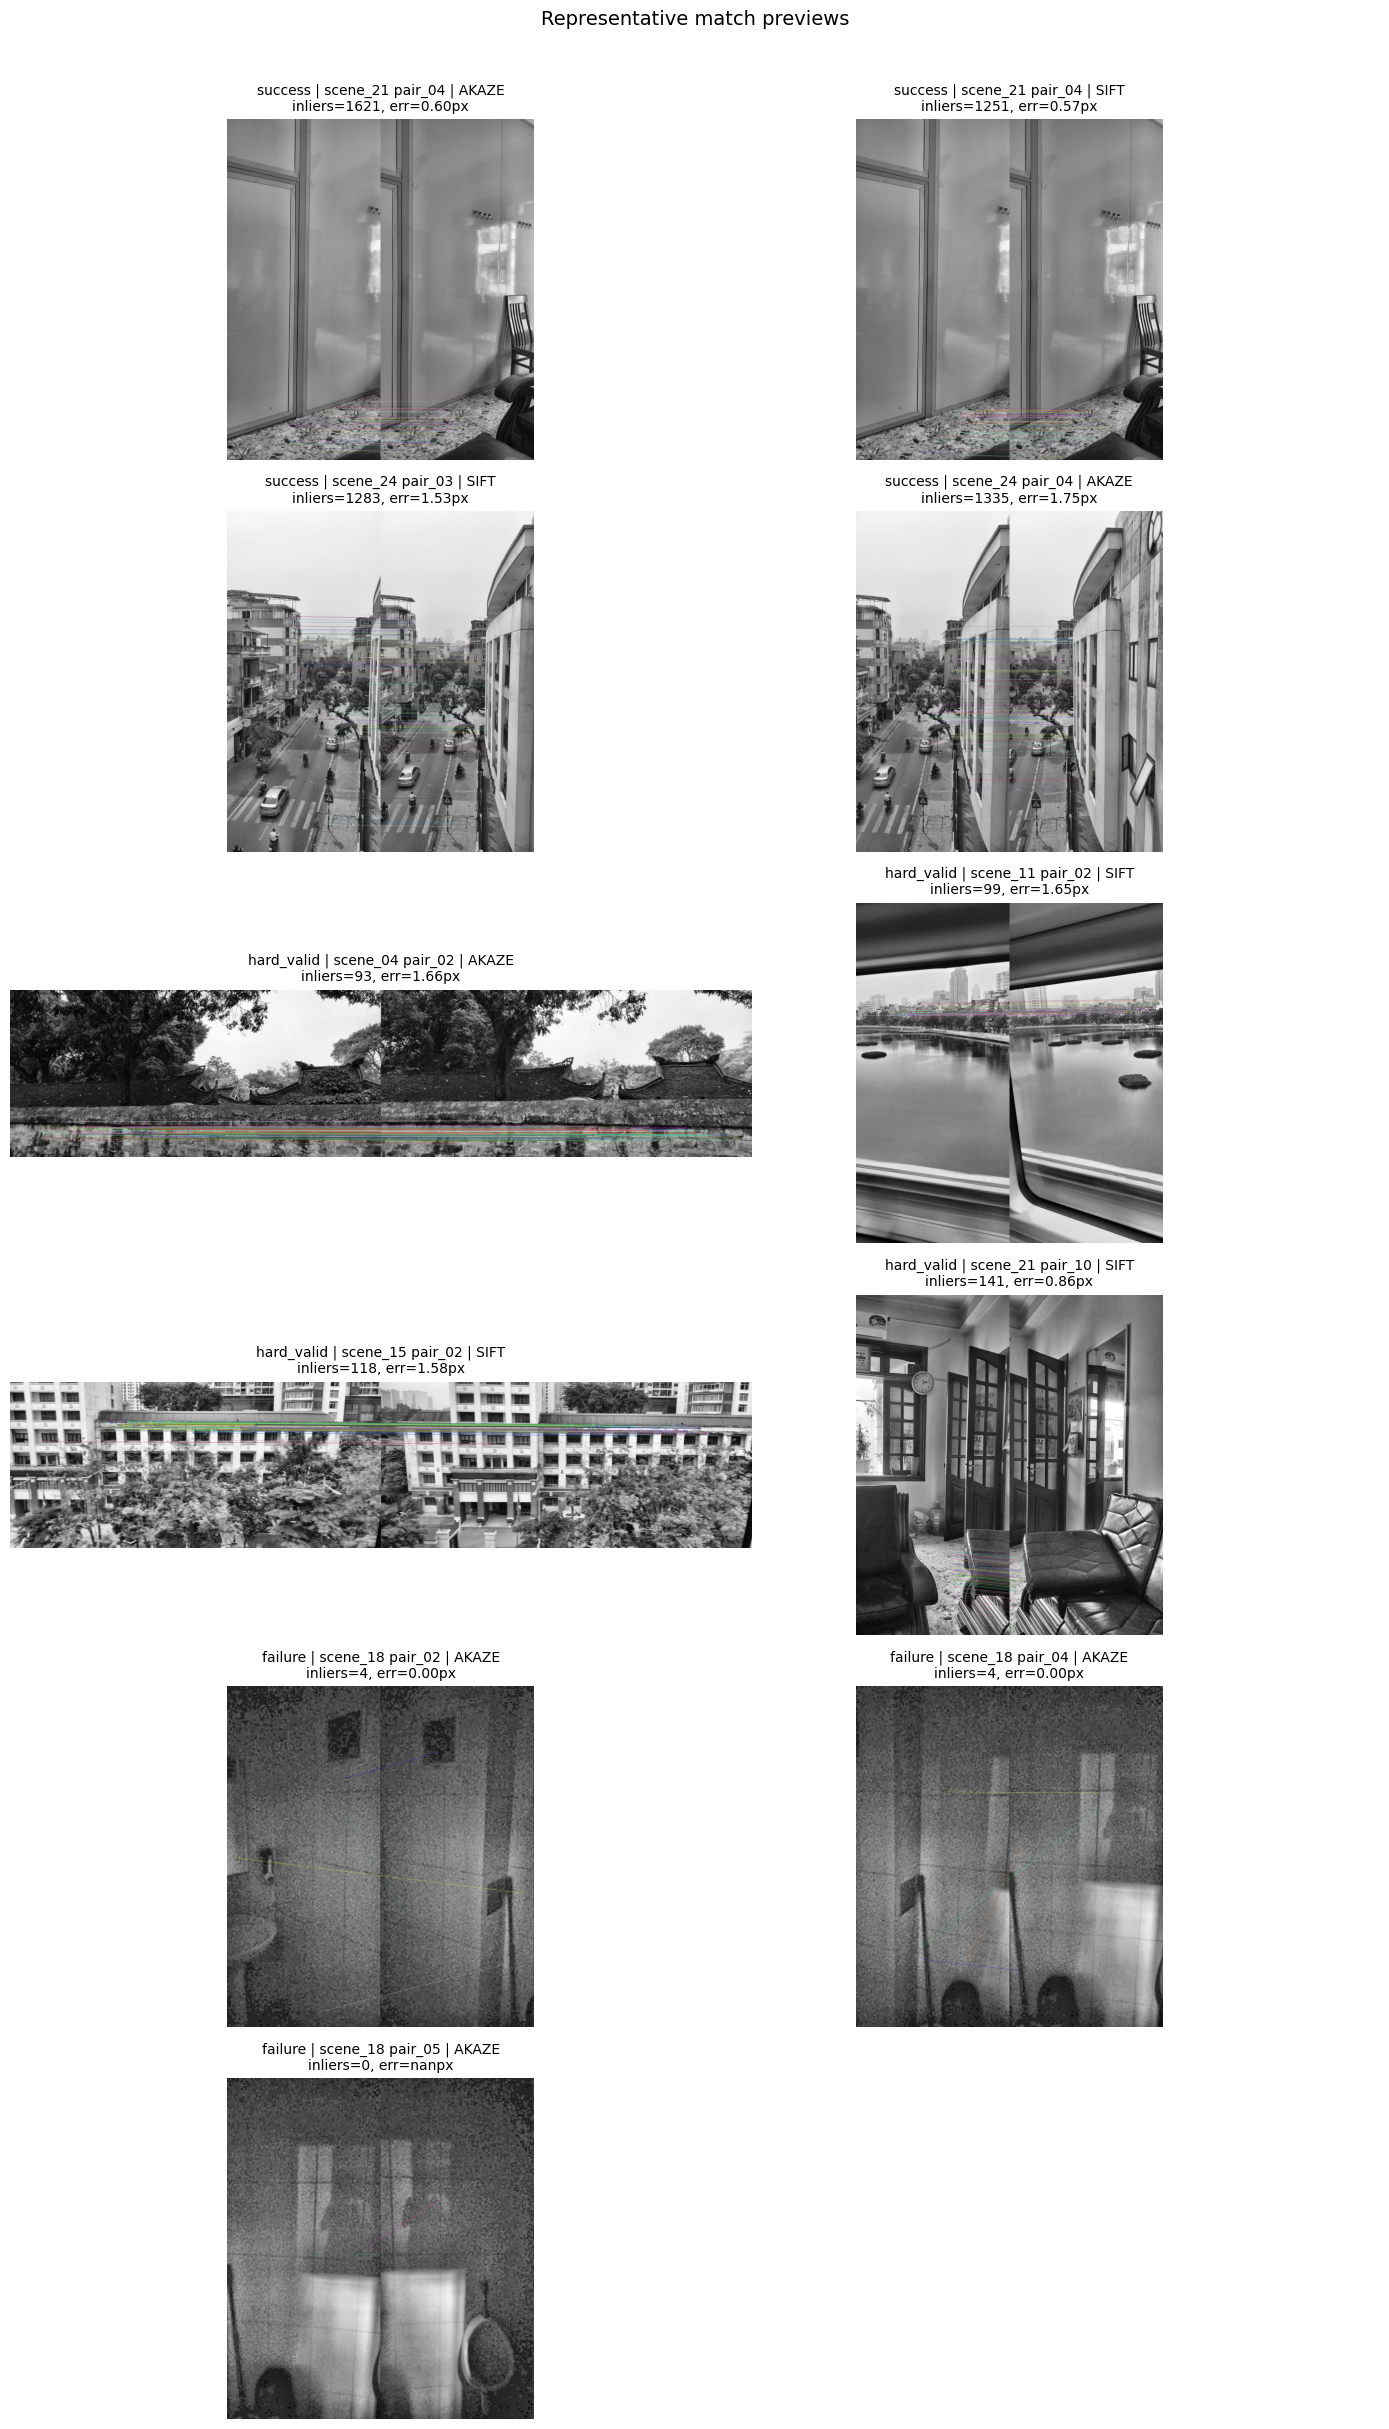

In [17]:
def resolve_preview_path(value: str) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def resize_for_montage(image: np.ndarray, width: int, height: int) -> np.ndarray:
    image_h, image_w = image.shape[:2]
    scale = min(width / max(image_w, 1), height / max(image_h, 1))
    new_w = max(1, int(round(image_w * scale)))
    new_h = max(1, int(round(image_h * scale)))
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    y0 = (height - new_h) // 2
    x0 = (width - new_w) // 2
    canvas[y0 : y0 + new_h, x0 : x0 + new_w] = resized
    return canvas


def draw_label_block(image: np.ndarray, title: str, subtitle: str, color: tuple[int, int, int]) -> np.ndarray:
    label_h = 82
    output = np.full((image.shape[0] + label_h, image.shape[1], 3), 255, dtype=np.uint8)
    output[label_h:, :] = image
    cv2.rectangle(output, (0, 0), (output.shape[1], label_h), color, thickness=-1)
    cv2.putText(output, title, (18, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(output, subtitle, (18, 62), cv2.FONT_HERSHEY_SIMPLEX, 0.56, (255, 255, 255), 1, cv2.LINE_AA)
    return output


def build_cv2_montage(montage_df: pd.DataFrame, output_path: Path, cols: int = 2) -> bool:
    tiles = []
    status_bgr = {
        "success": (74, 163, 22),
        "hard_valid": (11, 158, 245),
        "failure": (38, 38, 220),
    }
    for _, row in montage_df.iterrows():
        image_path = resolve_preview_path(row["preview_path"])
        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            continue
        tile = resize_for_montage(image_bgr, width=900, height=430)
        title = f"{row['status']} | {row['scene_id']} {row['pair_id']} | {row['method']}"
        subtitle = f"inliers={int(row['inliers'])}, err={float(row['reprojection_error_mean']):.2f}px"
        tile = draw_label_block(tile, title, subtitle, status_bgr.get(row["status"], (100, 116, 139)))
        tiles.append(tile)

    if not tiles:
        return False

    rows = int(math.ceil(len(tiles) / cols))
    tile_h, tile_w = tiles[0].shape[:2]
    gap = 18
    canvas_h = rows * tile_h + (rows + 1) * gap
    canvas_w = cols * tile_w + (cols + 1) * gap
    canvas = np.full((canvas_h, canvas_w, 3), 245, dtype=np.uint8)

    for index, tile in enumerate(tiles):
        row_i = index // cols
        col_i = index % cols
        y0 = gap + row_i * (tile_h + gap)
        x0 = gap + col_i * (tile_w + gap)
        canvas[y0 : y0 + tile_h, x0 : x0 + tile_w] = tile

    output_path.parent.mkdir(parents=True, exist_ok=True)
    return bool(cv2.imwrite(str(output_path), canvas))


if "preview_df" in globals() and not preview_df.empty:
    preview_order = pd.Categorical(preview_df["status"], categories=STATUS_ORDER, ordered=True)
    montage_df = preview_df.assign(_status_order=preview_order).sort_values(
        ["_status_order", "scene_id", "pair_id", "method"]
    )
    montage_df = montage_df.head(12)

    cv2_montage_path = PLOT_OUTPUT_DIR / "match_preview_montage.jpg"
    if build_cv2_montage(montage_df, cv2_montage_path, cols=2):
        print(f"Saved montage: {cv2_montage_path.relative_to(PROJECT_ROOT)}")
    else:
        print("Preview rows existed, but no preview images could be read for montage creation.")

    if HAS_MATPLOTLIB:
        cols = 2
        rows = int(math.ceil(len(montage_df) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 7.0, rows * 4.0))
        axes = np.atleast_1d(axes).ravel()

        for ax, (_, row) in zip(axes, montage_df.iterrows()):
            image_path = resolve_preview_path(row["preview_path"])
            image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
            if image_bgr is None:
                ax.axis("off")
                ax.set_title(f"Missing: {image_path.name}")
                continue
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            ax.imshow(image_rgb)
            ax.axis("off")
            title = (
                f"{row['status']} | {row['scene_id']} {row['pair_id']} | {row['method']}\n"
                f"inliers={int(row['inliers'])}, err={float(row['reprojection_error_mean']):.2f}px"
            )
            ax.set_title(title, fontsize=10)

        for ax in axes[len(montage_df):]:
            ax.axis("off")

        fig.suptitle("Representative match previews", y=1.01, fontsize=14)
        fig.tight_layout()
        save_plot(fig, "match_preview_montage.png")
        plt.show()
else:
    print("No preview rows were available for montage creation.")


## 14. Interpretation Notes
